# Final Comparison

In [2]:
import utils
import json
import numpy as np
import os
from utils import postprocess_responses
import math    
import numpy as np
from collections import defaultdict
from collections import Counter

np.random.seed(42)

c:\Users\nanfangwuyu\.conda\envs\RAG\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [64]:
lambdas_ = np.linspace(1, 30, 2000)[:100]
lambdas_[0], lambdas_[-1]

(np.float64(1.0), np.float64(2.4362181090545274))

In [42]:
import importlib
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\nanfangwuyu\\MyDrive\\WorkSpace\\CodeWorkSpace\\Master Thesis\\Master-Thesis-Beyond-Answer\\VLM CoT Task\\utils.py'>

In [4]:
# MODEL_LIST = ["pixtral", "gemma3_12b", "llama"]
# MODEL_LIST = ["pixtral", "gemma3_12b", "llama", "qwen_7b"]
# MODEL_LIST = ["pixtral", "gemma3_12b", "llama", "qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"]
MODEL_LIST = ["qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"]
# MODEL_LIST = ["pixtral", "gemma3_12b", "llama", "internvl3_14b", "qwen_3b", "qwen_7b", "qwen_32b"]
# MODEL_LIST = ["gemma3_12b"] 
# MODEL_LIST = ["pixtral", "gemma3_12b", "llama", "internvl3_14b"] 
# MODEL_LIST = ["llama", "qwen_72b", "llama", "qwen_72b"] 
# MODEL_LIST = ["qwen_3b", "qwen_7b"]
# MODEL_LIST = ["qwen_3b", "qwen_7b", "qwen_32b"]
settings = ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger'] 
# settings = ['cot_trigger', 'cot_trigger', 'cot_trigger'] 
# settings = ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger'] 
# settings = ['cot_trigger', 'cot_trigger'] 
# settings = ['ncot_force', 'ncot_force', 'ncot_force'] 
# settings = ['ncot_force', 'ncot_force', 'ncot_force', 'ncot_force'] 
# settings = ['cot_trigger', 'cot_trigger', 'ncot_force', 'ncot_force'] 
# MODEL_LIST = ["llama", "pixtral"]
# MODEL_LIST = ["gemma3_12b", "llama"]
# MODEL_LIST = ["pixtral", "gemma3_12b"]
# settings = ['ncot_force', 'ncot_force']
# DATASET_NAME = 'MathVista' 
DATASET_NAME = 'ScienceQA'
# DATASET_NAME = 'TQA'
# DATASET_NAME = 'MathVision' 
# DATASET_NAME = 'MMMU' 
# DATASET_NAME = 'MMStar'
ds = utils.load_dataset_(DATASET_NAME)
option_s = 'options' if 'options' in ds[0] else 'choices'
N = 16

In [5]:
np.random.seed(42)

In [6]:
# force_reprocess = True
force_reprocess = False

In [7]:
multi_cot_responses = []
multi_file_names = []
metas = []
for MODEL_NAME, setting in zip(MODEL_LIST, settings):
    metas.append((MODEL_NAME, setting))
    cot_responses_list, file_names = utils.load_latest_response(f'data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/responses_{MODEL_NAME}_{DATASET_NAME}_{setting}', N, debug=False)
    cot_responses = [utils.clean_responses(item, mode=MODEL_NAME, setting=setting) for item in cot_responses_list]
    file_names = [file_name.split('_')[-1].split('.')[0] for file_name in file_names]

    multi_cot_responses.append(cot_responses)
    multi_file_names.append(file_names)
print(N, min(len(x) for x in multi_file_names))
assert N == min(len(x) for x in multi_file_names)
assert len(ds) == len(multi_cot_responses[0][0])

16 16


In [8]:
multi_lst_AE_all, multi_match_list_all = [], []
for i, meta in enumerate(metas):
    MODEL_NAME, setting = meta
    lst_AE_all, match_list_all = postprocess_responses(ds, DATASET_NAME, MODEL_NAME, multi_cot_responses[i], multi_file_names[i], force_reprocess=force_reprocess)
    multi_lst_AE_all.append(lst_AE_all)
    multi_match_list_all.append(match_list_all)

Processing qwen_3b 034834 ...
Processing qwen_3b 071216 ...
Processing qwen_3b 205649 ...
Processing qwen_3b 002351 ...
Processing qwen_3b 203252 ...
Processing qwen_3b 203145 ...
Processing qwen_3b 171619 ...
Processing qwen_3b 171318 ...
Processing qwen_3b 140442 ...
Processing qwen_3b 135956 ...
Processing qwen_3b 042352 ...
Processing qwen_3b 104934 ...
Processing qwen_3b 104418 ...
Processing qwen_3b 073641 ...
Processing qwen_3b 073037 ...
Processing qwen_3b 041913 ...
Processing qwen_7b 113718 ...
Processing qwen_7b 070354 ...
Processing qwen_7b 215558 ...
Processing qwen_7b 022810 ...
Processing qwen_7b 010529 ...
Processing qwen_7b 004657 ...
Processing qwen_7b 210604 ...
Processing qwen_7b 205000 ...
Processing qwen_7b 051747 ...
Processing qwen_7b 171005 ...
Processing qwen_7b 165552 ...
Processing qwen_7b 131243 ...
Processing qwen_7b 130208 ...
Processing qwen_7b 091426 ...
Processing qwen_7b 091123 ...
Processing qwen_7b 051828 ...
Processing qwen_32b 162028 ...
Processin

In [9]:
option_lengths = [len(ops) for ops in ds[option_s]]

In [10]:
def calculate_entropy_distribution(ans_dist, n):
    
    def cal_entropy(answer_list):
        # -∑(p_i * log(p_i))

        counts = defaultdict(int)
        for answer in answer_list:
            if 0 <= answer <= 9:  # Assuming possible answers are in the range 0-9
                counts[answer] += 1
            else:
                print(f"Error! Idx {answer}")

        total_answers = len(answer_list)

        entropy = 0.0
        for count in counts.values():
            if count > 0:
                probability = count / total_answers
                entropy -= probability * math.log2(probability)

        max_count = max(counts.values())
        max_keys = [k for k, v in counts.items() if v == max_count]
        best_choice = np.random.choice(max_keys)

        return entropy, best_choice

    def cal_entropy_scipy(answer_list, len_ops):
        from scipy.stats import entropy

        # count for i in range (0, len_ops), each appears how many times
        counts = {i: np.sum(answer_list == i) for i in range(len_ops)}
        pk = np.array(list(counts.values()), dtype=float)
        # pk = [9,1,0,0,0]
        # print(pk)
        n = len_ops  # number of discrete categories
        H = entropy(pk, base=2)           
        # print(H)   # entropy in bits
        H_norm = H / (np.log2(n))              # normalized to max entropy of log2(n)

        max_count = max(counts.values())
        max_keys = [k for k, v in counts.items() if v == max_count]
        best_choice = np.random.choice(max_keys)
        return H_norm, best_choice

    entropy_distribution = []
    choice_list = []
    for j in range(len(ans_dist)):
        ans_dist_j = ans_dist[j][:n]
        # len_ops = len(ds[option_s][j])
        # entropy, best_choice = cal_entropy(ans_dist_j)
        entropy, best_choice = cal_entropy_scipy(ans_dist_j, len_ops=option_lengths[j])
        entropy_distribution.append(entropy)
        choice_list.append(best_choice)
    return entropy_distribution, choice_list

def calculate_majority_distribution(ans_dist, n):
    
    def cal_majority(answer_list):

        counts = defaultdict(int)
        for answer in answer_list:
            if 0 <= answer <= 9:
                counts[answer] += 1
            else:
                print(f"Error! Idx {answer}")

        # Find the majority choice (the most frequent answer)
        max_count = max(counts.values())
        max_keys = [k for k, v in counts.items() if v == max_count]
        majority_choice = np.random.choice(max_keys)
        return majority_choice

    choice_list = []
    for j in range(len(ans_dist)):
        ans_dist_j = ans_dist[j][:n]
        majority_choice = cal_majority(ans_dist_j)
        # If there is at least one correct answer
        choice_list.append(majority_choice)
    return choice_list


def calculate_accuracy(choice_list, idx_ground_truth):
    correct_count = sum(1 for i, choice in enumerate(choice_list) if choice == idx_ground_truth[i])
    accuracy = correct_count / len(idx_ground_truth)
    return accuracy

def calculate_match(choice_list, idx_ground_truth):
    match_list = [1 if choice == idx_ground_truth[i] else 0 for i, choice in enumerate(choice_list)]
    return match_list

In [11]:
idx_ground_truth = []
for i, ans in enumerate(ds['answer']):
    if DATASET_NAME in ["MathVista"]:
        idx_ground_truth.append(ds[option_s][i].index(ans))
    elif DATASET_NAME in ["ScienceQA", "TQA"]:
        idx_ground_truth.append(ans)
    else:
        chara_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
        idx_ground_truth.append(chara_list.index(ans))

In [12]:
set(idx_ground_truth), max([len(opt) for opt in ds[option_s]])  # Check if there are any special idx

({0, 1, 2, 3, 4}, 5)

In [13]:
def to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj


for i, meta in enumerate(metas):
    MODEL_NAME, setting = meta
    for j in range(len(multi_lst_AE_all[i])):
        lst_AE = multi_lst_AE_all[i][j]

        # Calculate the accuracy
        acc = calculate_accuracy(lst_AE, idx_ground_truth)
        
        # Calculate the match list
        match_list = calculate_match(lst_AE, idx_ground_truth)

        # Calculate the correct and wrong indices
        corr_indices = [i for i, x in enumerate(match_list) if x == 1]
        wrg_indices = [i for i, x in enumerate(match_list) if x == 0]

        # Responses
        corr_responses = [multi_cot_responses[i][j][k] for k in corr_indices]
        wrg_responses = [multi_cot_responses[i][j][k] for k in wrg_indices]

        data_json = json.dumps({
            'lst_AE': [to_serializable(x) for x in lst_AE],
            'acc': to_serializable(acc),
            'match_list': to_serializable(match_list),
            'corr_indices': to_serializable(corr_indices),
            'wrg_indices': to_serializable(wrg_indices),
            'corr_responses': corr_responses,
            'wrg_responses': wrg_responses
        }, ensure_ascii=False)
        # Save each JSON string to a file in the specified directory
        os.makedirs(f"data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/PostProcessing", exist_ok=True)
        with open(f"data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/PostProcessing/postprocess_{multi_file_names[i][j]}.json", "w", encoding="utf-8") as f:
            f.write(data_json)

In [14]:
multi_lst_AE_all = np.array(multi_lst_AE_all)
multi_ent_dist_all = []
multi_ent_choice_all = []
multi_ent_acc_all = []
multi_ent_match_all = []
for ans_dist in multi_lst_AE_all:
    ent_dist_all = []
    ent_choice_all = []
    ent_acc_all = []
    ent_match_all = []
    for n in range(1, N + 1):
        entropy_distribution, entropy_choices = calculate_entropy_distribution(ans_dist.T, n)
        ent_dist_all.append(entropy_distribution)
        ent_choice_all.append(entropy_choices)
        ent_acc_all.append(calculate_accuracy(entropy_choices, idx_ground_truth))
        ent_match_all.append(calculate_match(entropy_choices, idx_ground_truth))
    multi_ent_dist_all.append(ent_dist_all)
    multi_ent_choice_all.append(ent_choice_all)
    multi_ent_acc_all.append(ent_acc_all)
    multi_ent_match_all.append(ent_match_all)




In [15]:
multi_major_choice_all = []
multi_major_acc_all = []

for i, ans_dist in enumerate(multi_lst_AE_all):
    major_choice_all = []
    major_acc_all = []
    for n in range(1, N + 1):
        major_choices = calculate_majority_distribution(ans_dist.T, n)
        major_choice_all.append(major_choices)
        major_acc_all.append(calculate_accuracy(major_choices, idx_ground_truth))
    multi_major_choice_all.append(major_choice_all)
    multi_major_acc_all.append(major_acc_all)
    


In [16]:
multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
multi_ent_dist_all = np.array(multi_ent_dist_all)  # shape: (3, 16, 540)
multi_ent_choice_all = np.array(multi_ent_choice_all)  # shape: (3, 16, 540)
multi_ent_acc_all = np.array(multi_ent_acc_all) # shape: (3, 16)
multi_ent_match_all = np.array(multi_ent_match_all)  # shape: (3, 16, 540)
multi_major_choice_all = np.array(multi_major_choice_all)  # shape: (3, 16, 540)
multi_major_acc_all = np.array(multi_major_acc_all)  # shape: (3, 16)
multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)
multi_cot_responses.shape, multi_lst_AE_all.shape, multi_ent_dist_all.shape, multi_ent_choice_all.shape, multi_ent_acc_all.shape, multi_ent_match_all.shape, multi_major_choice_all.shape, multi_major_acc_all.shape, multi_match_list_all.shape

((4, 16, 2017),
 (4, 16, 2017),
 (4, 16, 2017),
 (4, 16, 2017),
 (4, 16),
 (4, 16, 2017),
 (4, 16, 2017),
 (4, 16),
 (4, 16, 2017))

In [17]:
q_id = 1
multi_lst_AE_all[0].T[q_id], multi_lst_AE_all[1].T[q_id], multi_lst_AE_all[2].T[q_id]

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [18]:
idx_ground_truth[q_id], ds['answer'][q_id]

(1, 1)

In [19]:
# multi_cot_responses[1].T[q_id]

In [20]:
# for i, resp in enumerate(multi_cot_responses[0][0][:20]):
#     print("-"*50)
#     print("ANSWER: \n")
#     print(resp)
#     print("GT: \n")
#     print(idx_ground_truth[i])
#     print('\n')

## Part 0 Upper bound

In [21]:
def cal_upper_bound_acc():
    """
    Calculate the upper bound accuracy
    There are m models and N rounds times answers for each question
    Suggest if there is any one correct, then the answer is correct.
    Which means the ensemble method will always smartly choose the correct answer as there is one.
    So, just need to calculate if multi_match_list_all.T is 1 for each row.
    """
    upper_bound_match = np.any(multi_match_list_all.T, axis=1)
    upper_bound_acc = np.mean(upper_bound_match)
    return upper_bound_acc, upper_bound_match

upper_bound_acc, upper_bound_match = cal_upper_bound_acc()
print(f"Upper bound accuracy: {upper_bound_acc:.4f}")

Upper bound accuracy: 0.9549


## Part 1 Mult-round

### Multi Round Average 

In [22]:
def cal_multi_round_avg_acc(n, debug=False):
    accs_list = []
    for i in range(len(metas)):
        accs = np.mean(multi_match_list_all[i][:n], axis=1)
        if debug:
            print(accs)
        accs_list.append(np.mean(accs))
    return accs_list

avg_acc = cal_multi_round_avg_acc(N)

# """ 
# find option first
# then extract after answer
# [0.53703704]
# [0.72037037]
# [0.77962963]
# extract after answer first
# then find option
# [0.5462963]
# [0.72777778]
# [0.78888889]
# """

# """
# not strip: 
# [0.78173516]
# [0.61369863]
# [0.71902588]
# [0.84109589]
# """
# """
# [0.56296296]
# [0.51481481]
# [0.70555556]
# """
# """
# [0.5037037]
# """

In [23]:
# this array has 3 dim, I want to cacluate the average of the dim 2 and 3
avg_ent = np.mean(multi_ent_dist_all, axis=(1, 2))

In [24]:
# # plot avg_acc and avg_ent
# # sort them together first
# sorted_zip = sorted(zip(avg_acc, avg_ent, MODEL_LIST), key=lambda x: x[1], reverse=True)
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.plot([x[0] for x in sorted_zip], label='Average Accuracy', marker='o')
# plt.plot([x[1] for x in sorted_zip], label='Average Entropy', marker='o')
# plt.title('Average Accuracy and Entropy for ' + DATASET_NAME)
# plt.xlabel('Model')
# plt.ylabel('Score')
# plt.xticks(range(len(MODEL_LIST)), [x[2] for x in sorted_zip], rotation=45)
# plt.legend()
# plt.grid()
# plt.tight_layout()
# plt.show()


In [ ]:
# mv_delta_all = dict()
setting = 'cot_trigger'

import pandas as pd
MODEL_LIST = ["llama", "pixtral", "gemma3_12b", "qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"]
settings = ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger']
DATASET_LIST = ["MathVista", "MathVision", "TQA", "ScienceQA", "MMStar", "MMMU"]

df = pd.DataFrame(columns=MODEL_LIST, index=DATASET_LIST)
for DATASET_NAME in DATASET_LIST:
    ds = utils.load_dataset_(DATASET_NAME)
    option_s = 'options' if 'options' in ds[0] else 'choices'
    N = 16
    np.random.seed(42)
    # force_reprocess = True
    force_reprocess = False
    multi_cot_responses = []
    multi_file_names = []
    metas = []
    for MODEL_NAME, setting in zip(MODEL_LIST, settings):
        metas.append((MODEL_NAME, setting))
        cot_responses_list, file_names = utils.load_latest_response(f'data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/responses_{MODEL_NAME}_{DATASET_NAME}_{setting}', N, debug=False)
        cot_responses = [utils.clean_responses(item, mode=MODEL_NAME, setting=setting) for item in cot_responses_list]
        file_names = [file_name.split('_')[-1].split('.')[0] for file_name in file_names]

        multi_cot_responses.append(cot_responses)
        multi_file_names.append(file_names)
    print(N, min(len(x) for x in multi_file_names))
    assert N == min(len(x) for x in multi_file_names)
    assert len(ds) == len(multi_cot_responses[0][0])
    multi_lst_AE_all, multi_match_list_all = [], []
    for i, meta in enumerate(metas):
        MODEL_NAME, setting = meta
        lst_AE_all, match_list_all = postprocess_responses(ds, DATASET_NAME, MODEL_NAME, multi_cot_responses[i], multi_file_names[i], force_reprocess=force_reprocess)
        multi_lst_AE_all.append(lst_AE_all)
        multi_match_list_all.append(match_list_all)
    option_lengths = [len(ops) for ops in ds[option_s]]
    idx_ground_truth = []
    for i, ans in enumerate(ds['answer']):
        if DATASET_NAME in ["MathVista"]:
            idx_ground_truth.append(ds[option_s][i].index(ans))
        elif DATASET_NAME in ["ScienceQA", "TQA"]:
            idx_ground_truth.append(ans)
        else:
            chara_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
            idx_ground_truth.append(chara_list.index(ans))
    multi_lst_AE_all = np.array(multi_lst_AE_all)
    multi_ent_dist_all = []
    multi_ent_choice_all = []
    multi_ent_acc_all = []
    multi_ent_match_all = []
    for ans_dist in multi_lst_AE_all:
        ent_dist_all = []
        ent_choice_all = []
        ent_acc_all = []
        ent_match_all = []
        for n in range(1, N + 1):
            entropy_distribution, entropy_choices = calculate_entropy_distribution(ans_dist.T, n)
            ent_dist_all.append(entropy_distribution)
            ent_choice_all.append(entropy_choices)
            ent_acc_all.append(calculate_accuracy(entropy_choices, idx_ground_truth))
            ent_match_all.append(calculate_match(entropy_choices, idx_ground_truth))
        multi_ent_dist_all.append(ent_dist_all)
        multi_ent_choice_all.append(ent_choice_all)
        multi_ent_acc_all.append(ent_acc_all)
        multi_ent_match_all.append(ent_match_all)

    multi_major_choice_all = []
    multi_major_acc_all = []

    for i, ans_dist in enumerate(multi_lst_AE_all):
        major_choice_all = []
        major_acc_all = []
        for n in range(1, N + 1):
            major_choices = calculate_majority_distribution(ans_dist.T, n)
            major_choice_all.append(major_choices)
            major_acc_all.append(calculate_accuracy(major_choices, idx_ground_truth))
        multi_major_choice_all.append(major_choice_all)
        multi_major_acc_all.append(major_acc_all)
        
    multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
    multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
    multi_ent_dist_all = np.array(multi_ent_dist_all)  # shape: (3, 16, 540)
    multi_ent_choice_all = np.array(multi_ent_choice_all)  # shape: (3, 16, 540)
    multi_ent_acc_all = np.array(multi_ent_acc_all) # shape: (3, 16)
    multi_ent_match_all = np.array(multi_ent_match_all)  # shape: (3, 16, 540)
    multi_major_choice_all = np.array(multi_major_choice_all)  # shape: (3, 16, 540)
    multi_major_acc_all = np.array(multi_major_acc_all)  # shape: (3, 16)
    multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)

    map_ = {
        'qwen_3b': 'Qwen-3B',
        'qwen_7b': 'Qwen-7B',
        'qwen_32b': 'Qwen-32B',
        'qwen_72b': 'Qwen-72B',
        'llama': 'LLaMA',
        'pixtral': 'Pixtral',
        'gemma3_12b': 'Gemma',
    }

    avg_acc = cal_multi_round_avg_acc(N)
    avg_ent = np.mean(multi_ent_dist_all, axis=(1, 2))

    sorted_zip = sorted(zip(avg_acc, avg_ent, MODEL_LIST), key=lambda x: x[1], reverse=True)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot([x[0] for x in sorted_zip], label='Average Accuracy', marker='o')
    plt.plot([x[1] for x in sorted_zip], label='Average Entropy', marker='o')
    plt.title('Average Accuracy and Entropy for ' + DATASET_NAME)
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.xticks(range(len(MODEL_LIST)), [x[2] for x in sorted_zip], rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print(f"Avg acc for dataset {DATASET_NAME}")
    for i, model in enumerate(MODEL_LIST):
        print(f"({map_[model]}, {avg_acc[i]})")

    print(f"Avg ent for dataset {DATASET_NAME}")
    for i, model in enumerate(MODEL_LIST):
        print(f"({map_[model]}, {avg_ent[i]})")




16 16
Processing llama 075345 ...
Processing llama 075215 ...
Processing llama 022037 ...
Processing llama 075059 ...
Processing llama 074709 ...
Processing llama 060530 ...
Processing llama 060521 ...
Processing llama 060337 ...
Processing llama 060108 ...
Processing llama 041507 ...
Processing llama 041418 ...
Processing llama 041401 ...
Processing llama 041012 ...
Processing llama 022735 ...
Processing llama 022353 ...
Processing llama 021651 ...
Processing pixtral 022022 ...
Processing pixtral 035635 ...
Processing pixtral 070958 ...
Processing pixtral 053321 ...
Processing pixtral 202052 ...
Processing pixtral 201045 ...
Processing pixtral 201630 ...
Processing pixtral 183922 ...
Processing pixtral 184249 ...
Processing pixtral 183641 ...
Processing pixtral 170530 ...
Processing pixtral 170201 ...
Processing pixtral 152659 ...
Processing pixtral 170135 ...
Processing pixtral 152712 ...
Processing pixtral 152310 ...
Processing gemma3_12b 032407 ...
Processing gemma3_12b 032158 ...


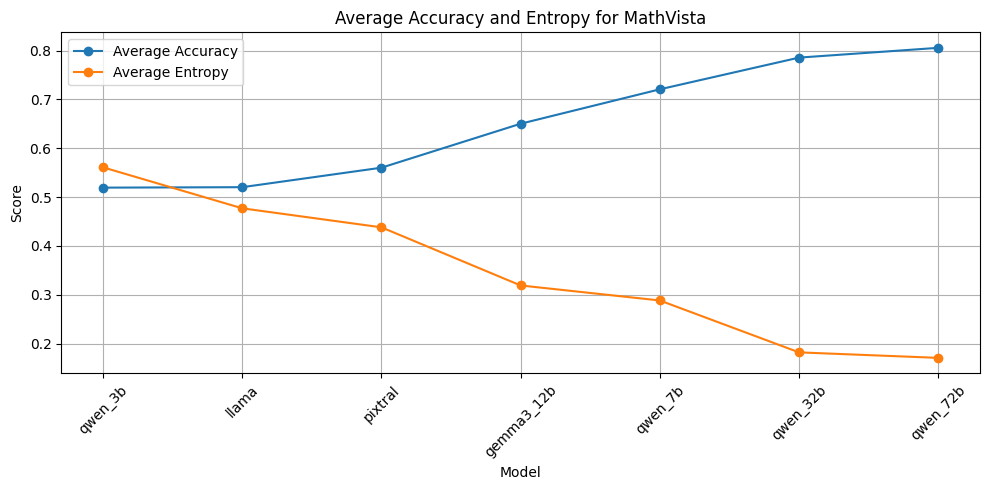

Avg acc for dataset MathVista
(Qwen-3B, 0.5194444444444444)
(LLaMA, 0.5203703703703704)
(Pixtral, 0.560300925925926)
(Gemma, 0.6503472222222222)
(Qwen-7B, 0.7208333333333333)
(Qwen-32B, 0.7857638888888888)
(Qwen-72B, 0.805787037037037)
Avg ent for dataset MathVista
(Qwen-3B, 0.5610214442606392)
(LLaMA, 0.477100606953641)
(Pixtral, 0.43812847503851154)
(Gemma, 0.31909536228134294)
(Qwen-7B, 0.28832551989156546)
(Qwen-32B, 0.18202658995058338)
(Qwen-72B, 0.1707680344509399)
Warning, you may use the wrong setting
16 16
Processing llama 023856 ...
Processing llama 023743 ...
Processing llama 023531 ...
Processing llama 023441 ...
Processing llama 023102 ...
Processing llama 022726 ...
Processing llama 022450 ...
Processing llama 022533 ...
Processing llama 022100 ...
Processing llama 021934 ...
Processing llama 021433 ...
Processing llama 020755 ...
Processing llama 021426 ...
Processing llama 021422 ...
Processing llama 021301 ...
Processing llama 021149 ...
Processing pixtral 080402 ...


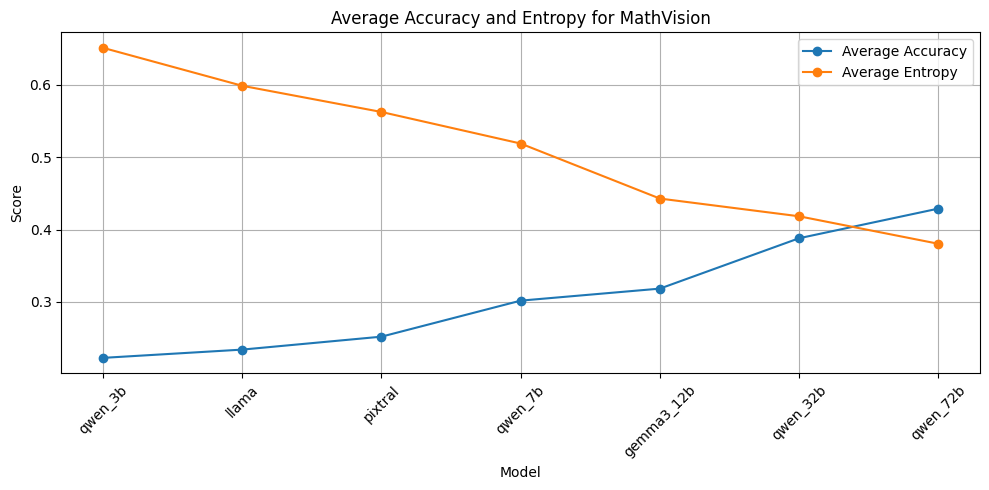

Avg acc for dataset MathVision
(Qwen-3B, 0.2227072454308094)
(LLaMA, 0.23413022193211488)
(Pixtral, 0.25199902088772846)
(Qwen-7B, 0.30177056135770236)
(Gemma, 0.3183746736292428)
(Qwen-32B, 0.38797323759791125)
(Qwen-72B, 0.42889197127937334)
Avg ent for dataset MathVision
(Qwen-3B, 0.6510414917202695)
(LLaMA, 0.5986063905973528)
(Pixtral, 0.5624257395543766)
(Qwen-7B, 0.5188211468461807)
(Gemma, 0.44281018585924997)
(Qwen-32B, 0.4183311082343801)
(Qwen-72B, 0.3803737151357536)
Warning, you may use the wrong setting
Warning, you may use the wrong setting
16 16
Processing llama 102140 ...
Processing llama 101645 ...
Processing llama 101114 ...
Processing llama 101113 ...
Processing llama 072606 ...
Processing llama 071312 ...
Processing llama 023728 ...
Processing llama 215039 ...
Processing llama 022824 ...
Processing llama 214540 ...
Processing llama 170602 ...
Processing llama 170151 ...
Processing llama 121938 ...
Processing llama 121522 ...
Processing llama 072827 ...
Processing l

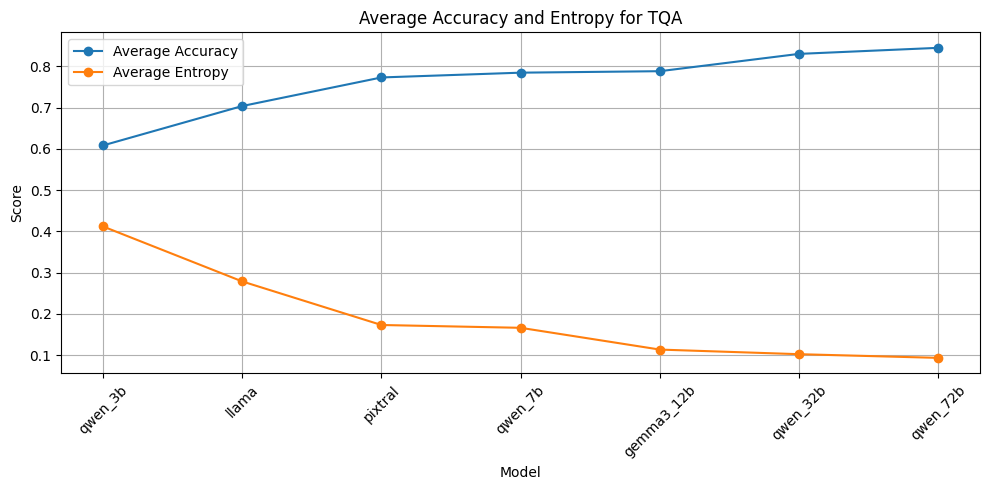

Avg acc for dataset TQA
(Qwen-3B, 0.6085235920852359)
(LLaMA, 0.7040715372907154)
(Pixtral, 0.7734208523592085)
(Qwen-7B, 0.785007610350076)
(Gemma, 0.7885844748858448)
(Qwen-32B, 0.8305745814307458)
(Qwen-72B, 0.8452435312024353)
Avg ent for dataset TQA
(Qwen-3B, 0.41193610185881857)
(LLaMA, 0.2786298609137217)
(Pixtral, 0.17296221031584375)
(Qwen-7B, 0.1661429419207665)
(Gemma, 0.11334712800159344)
(Qwen-32B, 0.1021751962285444)
(Qwen-72B, 0.09323779493803595)
16 16
Processing llama 150424 ...
Processing llama 101521 ...
Processing llama 030635 ...
Processing llama 081115 ...
Processing llama 021049 ...
Processing llama 020736 ...
Processing llama 220247 ...
Processing llama 220026 ...
Processing llama 175517 ...
Processing llama 053206 ...
Processing llama 175428 ...
Processing llama 134525 ...
Processing llama 134308 ...
Processing llama 093845 ...
Processing llama 093747 ...
Processing llama 052854 ...
Processing pixtral 015513 ...
Processing pixtral 011704 ...
Processing pixtral 

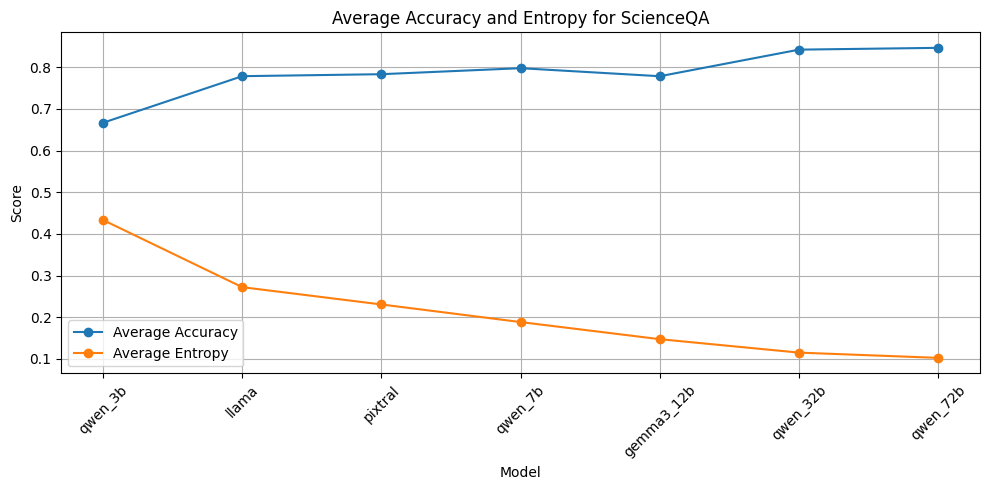

Avg acc for dataset ScienceQA
(Qwen-3B, 0.6666769955379277)
(LLaMA, 0.7784147248388696)
(Pixtral, 0.7831866633614278)
(Qwen-7B, 0.7975954387704511)
(Gemma, 0.7783217649975211)
(Qwen-32B, 0.8420922161626178)
(Qwen-72B, 0.8464303420922161)
Avg ent for dataset ScienceQA
(Qwen-3B, 0.4333736318931796)
(LLaMA, 0.27218115603337417)
(Pixtral, 0.23063060535913832)
(Qwen-7B, 0.18840331958236753)
(Gemma, 0.1473228008112682)
(Qwen-32B, 0.11511642065829153)
(Qwen-72B, 0.10251710898100455)
16 16
Processing llama 062727 ...
Processing llama 063048 ...
Processing llama 094231 ...
Processing llama 094832 ...
Processing llama 125741 ...
Processing llama 130723 ...
Processing llama 161236 ...
Processing llama 162344 ...
Processing llama 192924 ...
Processing llama 194100 ...
Processing llama 224552 ...
Processing llama 225730 ...
Processing llama 021651 ...
Processing llama 020204 ...
Processing llama 051652 ...
Processing llama 053254 ...
Processing pixtral 054748 ...
Processing pixtral 054815 ...
Proce

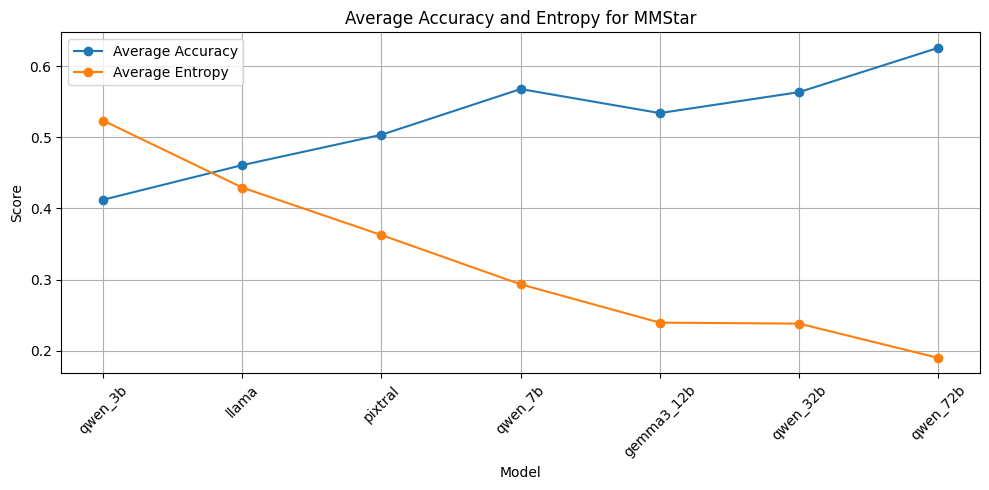

Avg acc for dataset MMStar
(Qwen-3B, 0.41225)
(LLaMA, 0.460875)
(Pixtral, 0.5035)
(Qwen-7B, 0.5677083333333334)
(Gemma, 0.5339583333333333)
(Qwen-32B, 0.5633750000000001)
(Qwen-72B, 0.6255833333333334)
Avg ent for dataset MMStar
(Qwen-3B, 0.52351072403509)
(LLaMA, 0.4293925809755607)
(Pixtral, 0.36267603965471623)
(Qwen-7B, 0.2935391288906788)
(Gemma, 0.23967371219214964)
(Qwen-32B, 0.23833517106448646)
(Qwen-72B, 0.19023091761638874)
16 16
Processing llama 203025 ...
Processing llama 172050 ...
Processing llama 202757 ...
Processing llama 171853 ...
Processing llama 140700 ...
Processing llama 140627 ...
Processing llama 221548 ...
Processing llama 105714 ...
Processing llama 105502 ...
Processing llama 074713 ...
Processing llama 074346 ...
Processing llama 043727 ...
Processing llama 043150 ...
Processing llama 012539 ...
Processing llama 012003 ...
Processing llama 220740 ...
Processing pixtral 213932 ...
Processing pixtral 214327 ...
Processing pixtral 002652 ...
Processing pixtra

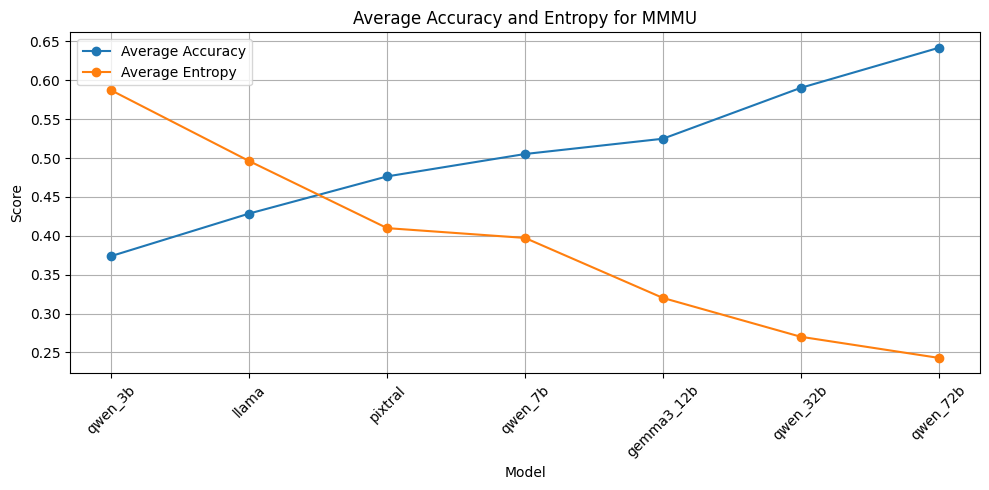

Avg acc for dataset MMMU
(Qwen-3B, 0.37406832298136644)
(LLaMA, 0.42872670807453417)
(Pixtral, 0.4764751552795031)
(Qwen-7B, 0.5052795031055901)
(Gemma, 0.5249223602484472)
(Qwen-32B, 0.5903726708074535)
(Qwen-72B, 0.6418478260869565)
Avg ent for dataset MMMU
(Qwen-3B, 0.5870964701703758)
(LLaMA, 0.49615147426068584)
(Pixtral, 0.40994098682755964)
(Qwen-7B, 0.39733350724525984)
(Gemma, 0.3201634394253336)
(Qwen-32B, 0.270197942542754)
(Qwen-72B, 0.24305671238425539)
Overall datasets average accuracy:
(Qwen-3B, 0.4672784334132973)
(LLaMA, 0.5210980937511008)
(Pixtral, 0.5581471029689656)
(Qwen-7B, 0.6130324633750811)
(Gemma, 0.5990848048861018)
(Qwen-32B, 0.6666919324812696)
(Qwen-72B, 0.6989640068385586)
Overall datasets average entropy:
(Qwen-3B, 0.5279966439897288)
(LLaMA, 0.425343678289056)
(Pixtral, 0.36279400945835766)
(Qwen-7B, 0.3087609273961365)
(Gemma, 0.2637354380951563)
(Qwen-32B, 0.22103040477984)
(Qwen-72B, 0.19669738058439634)


In [30]:
# mv_delta_all = dict()
setting = 'cot_trigger'

import pandas as pd
MODEL_LIST = ["llama", "pixtral", "gemma3_12b", "qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"]
settings = ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger']
DATASET_LIST = ["MathVista", "MathVision", "TQA", "ScienceQA", "MMStar", "MMMU"]

df = pd.DataFrame(columns=MODEL_LIST, index=DATASET_LIST)

all_avg_acc = []
all_avg_ent = []
for DATASET_NAME in DATASET_LIST:
    ds = utils.load_dataset_(DATASET_NAME)
    option_s = 'options' if 'options' in ds[0] else 'choices'
    N = 16
    np.random.seed(42)
    # force_reprocess = True
    force_reprocess = False
    multi_cot_responses = []
    multi_file_names = []
    metas = []
    for MODEL_NAME, setting in zip(MODEL_LIST, settings):
        metas.append((MODEL_NAME, setting))
        cot_responses_list, file_names = utils.load_latest_response(f'data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/responses_{MODEL_NAME}_{DATASET_NAME}_{setting}', N, debug=False)
        cot_responses = [utils.clean_responses(item, mode=MODEL_NAME, setting=setting) for item in cot_responses_list]
        file_names = [file_name.split('_')[-1].split('.')[0] for file_name in file_names]

        multi_cot_responses.append(cot_responses)
        multi_file_names.append(file_names)
    print(N, min(len(x) for x in multi_file_names))
    assert N == min(len(x) for x in multi_file_names)
    assert len(ds) == len(multi_cot_responses[0][0])
    multi_lst_AE_all, multi_match_list_all = [], []
    for i, meta in enumerate(metas):
        MODEL_NAME, setting = meta
        lst_AE_all, match_list_all = postprocess_responses(ds, DATASET_NAME, MODEL_NAME, multi_cot_responses[i], multi_file_names[i], force_reprocess=force_reprocess)
        multi_lst_AE_all.append(lst_AE_all)
        multi_match_list_all.append(match_list_all)
    option_lengths = [len(ops) for ops in ds[option_s]]
    idx_ground_truth = []
    for i, ans in enumerate(ds['answer']):
        if DATASET_NAME in ["MathVista"]:
            idx_ground_truth.append(ds[option_s][i].index(ans))
        elif DATASET_NAME in ["ScienceQA", "TQA"]:
            idx_ground_truth.append(ans)
        else:
            chara_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
            idx_ground_truth.append(chara_list.index(ans))
    multi_lst_AE_all = np.array(multi_lst_AE_all)
    multi_ent_dist_all = []
    multi_ent_choice_all = []
    multi_ent_acc_all = []
    multi_ent_match_all = []
    for ans_dist in multi_lst_AE_all:
        ent_dist_all = []
        ent_choice_all = []
        ent_acc_all = []
        ent_match_all = []
        for n in range(1, N + 1):
            entropy_distribution, entropy_choices = calculate_entropy_distribution(ans_dist.T, n)
            ent_dist_all.append(entropy_distribution)
            ent_choice_all.append(entropy_choices)
            ent_acc_all.append(calculate_accuracy(entropy_choices, idx_ground_truth))
            ent_match_all.append(calculate_match(entropy_choices, idx_ground_truth))
        multi_ent_dist_all.append(ent_dist_all)
        multi_ent_choice_all.append(ent_choice_all)
        multi_ent_acc_all.append(ent_acc_all)
        multi_ent_match_all.append(ent_match_all)

    multi_major_choice_all = []
    multi_major_acc_all = []

    for i, ans_dist in enumerate(multi_lst_AE_all):
        major_choice_all = []
        major_acc_all = []
        for n in range(1, N + 1):
            major_choices = calculate_majority_distribution(ans_dist.T, n)
            major_choice_all.append(major_choices)
            major_acc_all.append(calculate_accuracy(major_choices, idx_ground_truth))
        multi_major_choice_all.append(major_choice_all)
        multi_major_acc_all.append(major_acc_all)
        
    multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
    multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
    multi_ent_dist_all = np.array(multi_ent_dist_all)  # shape: (3, 16, 540)
    multi_ent_choice_all = np.array(multi_ent_choice_all)  # shape: (3, 16, 540)
    multi_ent_acc_all = np.array(multi_ent_acc_all) # shape: (3, 16)
    multi_ent_match_all = np.array(multi_ent_match_all)  # shape: (3, 16, 540)
    multi_major_choice_all = np.array(multi_major_choice_all)  # shape: (3, 16, 540)
    multi_major_acc_all = np.array(multi_major_acc_all)  # shape: (3, 16)
    multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)

    map_ = {
        'qwen_3b': 'Qwen-3B',
        'qwen_7b': 'Qwen-7B',
        'qwen_32b': 'Qwen-32B',
        'qwen_72b': 'Qwen-72B',
        'llama': 'LLaMA',
        'pixtral': 'Pixtral',
        'gemma3_12b': 'Gemma',
    }

    avg_acc = cal_multi_round_avg_acc(N)
    avg_ent = np.mean(multi_ent_dist_all, axis=(1, 2))

    sorted_zip = sorted(zip(avg_acc, avg_ent, MODEL_LIST), key=lambda x: x[1], reverse=True)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot([x[0] for x in sorted_zip], label='Average Accuracy', marker='o')
    plt.plot([x[1] for x in sorted_zip], label='Average Entropy', marker='o')
    plt.title('Average Accuracy and Entropy for ' + DATASET_NAME)
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.xticks(range(len(MODEL_LIST)), [x[2] for x in sorted_zip], rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print(f"Avg acc for dataset {DATASET_NAME}")
    for i, x in enumerate(sorted_zip):
        print(f"({map_[x[2]]}, {x[0]})")

    print(f"Avg ent for dataset {DATASET_NAME}")
    for i, x in enumerate(sorted_zip):
        print(f"({map_[x[2]]}, {x[1]})")

    all_avg_acc.append(avg_acc)
    all_avg_ent.append(avg_ent)

mean_all_avg_acc = np.mean(np.array(all_avg_acc), axis=0)
mean_all_avg_ent = np.mean(np.array(all_avg_ent), axis=0)
sorted_zip = sorted(zip(mean_all_avg_acc, mean_all_avg_ent, MODEL_LIST), key=lambda x: x[1], reverse=True)


print("Overall datasets average accuracy:")
for i, x in enumerate(sorted_zip):
    print(f"({map_[x[2]]}, {x[0]})")

print("Overall datasets average entropy:")
for i, x in enumerate(sorted_zip):
    print(f"({map_[x[2]]}, {x[1]})")


### Multi Round Maximum

In [24]:
def cal_multi_round_max_acc(n, debug=False):
    accs_list = []
    for i in range(len(metas)):
        accs = np.mean(multi_match_list_all[i][:n], axis=1)
        if debug:
            print(accs)
        accs_list.append(np.max(accs))
    return accs_list

cal_multi_round_max_acc(N, True)



[0.66732771 0.66137828 0.66683193 0.64402578 0.66633614 0.66831929
 0.67773922 0.664353   0.66881507 0.66038671 0.67030243 0.67178979
 0.68071393 0.67278136 0.65840357 0.66732771]
[0.80118989 0.7902826  0.78978681 0.79871096 0.80614774 0.79077838
 0.78879524 0.80466039 0.79821517 0.79127417 0.79771939 0.80267724
 0.79821517 0.80168567 0.79821517 0.80317303]
[0.84581061 0.83936539 0.83986118 0.8463064  0.84581061 0.83986118
 0.83490332 0.84432325 0.84085275 0.83539911 0.84581061 0.83986118
 0.84928111 0.84581061 0.84184432 0.83837382]
[0.84035697 0.85076847 0.84729797 0.84481904 0.84680218 0.84333168
 0.84828954 0.84878532 0.83639068 0.84581061 0.85423897 0.84531482
 0.85225583 0.83936539 0.84828954 0.85076847]


[np.float64(0.6807139315815568),
 np.float64(0.8061477441745166),
 np.float64(0.849281110560238),
 np.float64(0.8542389687654933)]

### Length

In [25]:
import spacy
nlp = spacy.load("en_core_web_sm")
from tqdm import tqdm

In [26]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nanfangwuyu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


TODO
1. ~~clean pixtral, why not clean? ncot~~
2. ~~choose suitable tokenizer~~

In [27]:
import re
def length_list(responses):
    lengths = []
    for response in responses:
        # doc = nlp(response)
        # words = [token.text for token in doc if not token.is_space and not token.is_punct]
        # words = re.findall(r"\w+", response.lower())
        words = word_tokenize(response)
        # print(words)
        lengths.append(len(words))
    return lengths


def cal_multi_round_length(n, debug=False):
    acc_list = []
    for i in range(len(metas)):
        cot_responses = multi_cot_responses[i].T # shape: (540, 16)
        pivot_acc_list = []
        for j in tqdm(range(len(cot_responses))):
            lengths = length_list(cot_responses[j][:n])
            pivot_choice_id = np.argmax(lengths)
            pivot_acc = multi_match_list_all[i][pivot_choice_id][j]
            pivot_acc_list.append(pivot_acc)
        pivot_acc = np.mean(pivot_acc_list)
        acc_list.append(pivot_acc)
        print(f"Model: {metas[i][0]}, Setting: {metas[i][1]}, N: {n}, Max Lennth Accuracy: {pivot_acc}")

    return acc_list
       
cal_multi_round_length(N, True)


100%|██████████| 2017/2017 [00:30<00:00, 65.33it/s]


Model: qwen_3b, Setting: cot_trigger, N: 16, Max Lennth Accuracy: 0.6370847793753098


100%|██████████| 2017/2017 [00:45<00:00, 44.01it/s]


Model: qwen_7b, Setting: cot_trigger, N: 16, Max Lennth Accuracy: 0.7848289538919186


100%|██████████| 2017/2017 [01:08<00:00, 29.32it/s]


Model: qwen_32b, Setting: cot_trigger, N: 16, Max Lennth Accuracy: 0.8393653941497273


100%|██████████| 2017/2017 [00:50<00:00, 39.98it/s]

Model: qwen_72b, Setting: cot_trigger, N: 16, Max Lennth Accuracy: 0.8383738225086762


[np.float64(0.6370847793753098),
 np.float64(0.7848289538919186),
 np.float64(0.8393653941497273),
 np.float64(0.8383738225086762)]

### Pivot Phrases

In [33]:
with open("data/cot_pivots_phrases/pivot_phrases.txt", 'rb') as f:
    cot_pivots_phrases = [p.strip().lower() for p in f.read().decode('utf-8').split(',')]


In [29]:

import editdistance
import re

def fuzzy_count_editdistance(text, threshold_ratio=0.9):
    # very simple tokenization
    tokens = re.findall(r"\w+", text.lower())
    clusters = []
    for tok in tokens:
        matched = False
        for rep in clusters:
            dist = editdistance.eval(tok, rep)
            max_len = max(len(tok), len(rep))
            sim_ratio = 1 - dist / max_len
            if sim_ratio >= threshold_ratio:
                matched = True
                break
        if not matched:
            clusters.append(tok)
    print(tokens)
    return len(clusters)

# Example
text = "oh, oh! ooh ohh colours color"
print(fuzzy_count_editdistance(text, threshold_ratio=0.9))

['oh', 'oh', 'ooh', 'ohh', 'colours', 'color']
5


In [34]:
from fuzzywuzzy import fuzz
import re

def count_pivot_phrases(text, use_fuzzy=False, fuzzy_threshold=80):
    """
    Count the total number of appearances of pivot phrases in a given text.
    
    Parameters:
    text (str): The input text to search for pivot phrases
    use_fuzzy (bool): Whether to use fuzzy matching (default: False)
    fuzzy_threshold (int): Minimum similarity score for fuzzy matching (default: 90)
    
    Returns:
    int: Total count of pivot phrase appearances
    """
    
    cot_pivots_phrases = [
        'wait', 
        'oh', 
        'actually', 
        'i missed something', 
        'let me doublecheck', 
        'to verify', 
        'checking again', 
        'what if', 
        'another way to look at this', 
        'alternatively', 
        'now i see how', 
        'this connects back to', 
        'putting this together'
    ]
    
    # Convert text to lowercase for case-insensitive matching
    text_lower = text.lower()
    
    total_count = 0
    
    if not use_fuzzy:
        # Exact matching (case-insensitive)
        for phrase in cot_pivots_phrases:
            # Count non-overlapping occurrences
            count = len(re.findall(re.escape(phrase), text_lower))
            total_count += count
    else:
        # Fuzzy matching
        # Split text into words and create sliding windows of different sizes
        words = re.findall(r"\w+", text_lower)

        matched_positions = set()  # Track positions to avoid double counting
        
        for phrase in cot_pivots_phrases:
            phrase_words = phrase.split()
            phrase_length = len(phrase_words)
            
            # Create sliding windows of the same length as the phrase
            for i in range(len(words) - phrase_length + 1):
                if i in matched_positions:
                    continue
                    
                window = ' '.join(words[i:i + phrase_length])
                similarity = fuzz.ratio(phrase, window)
                
                # dist = editdistance.eval(phrase, window)
                # max_len = max(len(phrase), len(window))
                # similarity = 1 - dist / max_len
                # if similarity >= fuzzy_threshold:
                #     print(phrase, window, similarity, words[:i + phrase_length+20])

                if similarity >= fuzzy_threshold:
                    total_count += 1
                    # Mark all positions in this window as matched
                    for j in range(i, i + phrase_length):
                        matched_positions.add(j)
    
    return total_count

In [35]:
def count_pivots(responses, pivot_phrases):
    pivot_counts = []
    for response in responses:
        # pivot_cnt = 0
        # lower_response = response.lower()
        # for pivot in pivot_phrases:
        #     if pivot in lower_response:
        #         pivot_cnt += 1
        # pivot_counts.append(round(pivot_cnt / (len(response) + 1e-6), 4))
        pivot_cnt = count_pivot_phrases(response, use_fuzzy=True, fuzzy_threshold=80)
        pivot_counts.append(pivot_cnt)
    # print(sum(pivot_counts))
    return pivot_counts

def cal_pivot_acc(n):
    acc_list = []
    pivot_count_list = []
    for i in range(len(metas)):
        cot_responses = multi_cot_responses[i].T # shape: (540, 16)
        pivot_acc_list = []
        for j in range(len(cot_responses)):
            pivot_counts = count_pivots(cot_responses[j][:n], cot_pivots_phrases)
            pivot_choice_id = np.argmax(pivot_counts)
            pivot_acc = multi_match_list_all[i][pivot_choice_id][j]
            pivot_acc_list.append(pivot_acc)
            pivot_count_list.append(pivot_counts)
        # break
        print(np.sum(np.array(pivot_count_list)))
        print(len(pivot_acc_list), sum(pivot_acc_list))
        pivot_acc = np.mean(pivot_acc_list)
        acc_list.append(pivot_acc)
        print(f"Model: {metas[i][0]}, Setting: {metas[i][1]}, N: {n}, Pivot Accuracy: {pivot_acc}")

    return acc_list
       

# cal_pivot_acc(N)  

### Multi Round Voting

In [16]:
def cal_multi_round_voting(n):
    accs_list = []
    for i in range(len(metas)):
        accs = multi_major_acc_all[i][:n]
        accs_list.append(np.mean(accs))
    return accs_list

cal_multi_round_voting(N)

[np.float64(0.773263888888889)]

## Part 2 Multi-Model

### Vallina

In [41]:
def cal_multi_model_avg_acc(n):
    accs_all = []
    for i in range(len(metas)):
        accs = np.mean(multi_match_list_all[i][:n], axis=1)
        accs_all.append(np.mean(accs))
    return np.mean(accs_all)

cal_multi_model_avg_acc(N)

np.float64(0.7881987481408032)

### Pivot

In [42]:
def cal_pivot_multi_model_acc(n):
    multi_cot_responses_T = multi_cot_responses.T # shape: (540, 16, 3)
    # j for question, i for model
    pivot_acc_list = []
    for j in range(len(multi_cot_responses_T)):
        cot_responses = multi_cot_responses_T[j].T # shape: (3, 16)
        pivot_count_list = []
        for i in range(len(cot_responses)):
            pivot_counts = count_pivots(cot_responses[i][:n], cot_pivots_phrases)
            pivot_count_list.append(pivot_counts)
        pivot_count_list = np.array(pivot_count_list)
        pivot_choice_id = np.unravel_index(np.argmax(pivot_count_list, axis=None), pivot_count_list.shape)
        # print(pivot_choice_id)
        pivot_acc = multi_match_list_all[pivot_choice_id[0]][pivot_choice_id[1]][j]
        pivot_acc_list.append(pivot_acc)
    pivot_acc = np.mean(pivot_acc_list)
    print(f"Pivot Accuracy: {pivot_acc:.4f}")
    return pivot_acc

### Majority Voting

In [47]:
def cal_multi_model_major_acc(n):
    multi_major_choice_all_T = multi_major_choice_all.T  # shape: (540, 16, 3)
    final_choice_list = []
    for j in range(len(multi_major_choice_all_T)):
        choice_counter = Counter(multi_major_choice_all_T[j][n-1])
        final_choice = choice_counter.most_common(1)[0][0]
        final_choice_list.append(final_choice)
    final_acc = calculate_accuracy(final_choice_list, idx_ground_truth)
    print(f"Majority Voting Accuracy: {final_acc}")
    return final_acc

cal_multi_model_major_acc(N)

Majority Voting Accuracy: 0.8314814814814815


0.8314814814814815

### One-step voting

In [46]:
def cal_multi_model_major_acc_one_step(n):
    multi_lst_AE_all_T = multi_lst_AE_all.T  # shape: (540, 16, 3)
    final_choice_list = []
    for j in range(len(multi_lst_AE_all_T)):
        choice_counter = Counter(multi_lst_AE_all_T[j][:n].flatten())
        final_choice = choice_counter.most_common(1)[0][0]
        final_choice_list.append(final_choice)
    final_acc = calculate_accuracy(final_choice_list, idx_ground_truth)
    print(f"Majority Voting Accuracy: {final_acc}")
    return final_acc

cal_multi_model_major_acc_one_step(N)

Majority Voting Accuracy: 0.8462962962962963


0.8462962962962963

### Entropy Method (No Prior)

In [45]:
def cal_multi_model_ent_acc_no_prior(n):
    multi_ent_choice_all_T = multi_ent_choice_all.T  # shape: (540, 16, 3)
    multi_ent_dist_all_T = multi_ent_dist_all.T  # shape: (540, 16, 3)
    final_choice_list = []
    for j in range(len(multi_ent_choice_all_T)):
        entropy_distribution = multi_ent_dist_all_T[j][n-1]
        final_choice = multi_ent_choice_all_T[j][n-1][np.argmin(entropy_distribution)]
        final_choice_list.append(final_choice)
    final_acc = calculate_accuracy(final_choice_list, idx_ground_truth)
    print(f"Entropy Voting Accuracy: {final_acc}")
    return final_acc

cal_multi_model_ent_acc_no_prior(N)

Entropy Voting Accuracy: 0.8444444444444444


0.8444444444444444

### Entropy (No Prior) + Voting Mixed

In [49]:
def cal_multi_model_ent_acc_no_prior_major_mixed(n):
    multi_ent_choice_all_T = multi_ent_choice_all.T  # shape: (540, 16, 3)
    multi_ent_dist_all_T = multi_ent_dist_all.T  # shape: (540, 16, 3)
    final_choice_list = []
    for j in range(len(multi_ent_choice_all_T)):
        entropy_distribution = multi_ent_dist_all_T[j][n-1]
        # Get all indices with minimum entropy
        min_entropy = np.min(entropy_distribution)
        min_indices = np.where(entropy_distribution == min_entropy)[0]
        # If multiple models have same min entropy, use majority voting among them
        if len(min_indices) > 1:
            
            choices = [multi_ent_choice_all_T[j][n-1][idx] for idx in min_indices]
            if len(set(choices)) == 1:
                final_choice = choices[0]
            else:
                all_choices = multi_ent_choice_all_T[j][n-1]
                # Calculate majority voting among all models
                choice_counter = Counter(all_choices)
                majority_choice = choice_counter.most_common(1)[0][0]
                # Check if any of the min entropy models chose the majority choice
                if majority_choice in choices:
                    final_choice = majority_choice
                else:
                    # If majority choice is not among min entropy choices, pick first min entropy choice
                    final_choice = choices[0]
        else:
            final_choice = multi_ent_choice_all_T[j][n-1][min_indices[0]]
        final_choice_list.append(final_choice)
    final_acc = calculate_accuracy(final_choice_list, idx_ground_truth)
    print(f"Entropy Voting Accuracy: {final_acc}")
    return final_acc

cal_multi_model_ent_acc_no_prior_major_mixed(N)





Entropy Voting Accuracy: 0.856717897868121


0.856717897868121

### Entropy Method (Prior)

#### Training

In [57]:
# 对所有模型的 entropy 进行 min-max normalize，取 n=16 (N) 时的 entropy
# 然后得到例如X: [ent0, ent1, ent2] y: [0, 0, 1] (前两模型错误，第三模型正确) 的 训练集

ent_min = np.min(multi_ent_dist_all)
ent_max = np.max(multi_ent_dist_all)

# 提取 n=N 时的 entropy 并进行 min-max 归一化
multi_ent_norm_N = []
for i in range(multi_ent_dist_all.shape[0]):  # 遍历每个模型
    ent = multi_ent_dist_all[i][N-1]  # shape: (540,), 取第N个(索引N-1)
    ent_norm = (ent - ent_min) / (ent_max - ent_min) if ent_max > ent_min else np.zeros_like(ent)
    multi_ent_norm_N.append(ent_norm)

multi_ent_norm_N = np.stack(multi_ent_norm_N, axis=1)  # shape: (540, 3)

# 提取 n=N 时的准确率
multi_ent_acc_N = multi_ent_match_all[:, N-1].T  # shape: (540, 3)

# 构造训练数据
X = np.concatenate([multi_ent_dist_all[:, N-1].T], axis=1)
from sklearn.preprocessing import minmax_scale
X_norm = minmax_scale(X, axis=1)  # 对每一列进行 min-max 归一化
y = multi_ent_acc_N
X = np.concatenate([X, X_norm], axis=1)  # shape: (540, 6)
X[:3], X_norm[:3], y[:3]

(array([[0.79595859, 0.56082038, 0.        , 0.        , 1.        ,
         0.70458487, 0.        , 0.        ],
        [0.85140977, 0.94142803, 0.        , 0.34810613, 0.90438115,
         1.        , 0.        , 0.36976393],
        [0.90251827, 0.27178222, 0.        , 0.        , 1.        ,
         0.30113764, 0.        , 0.        ]]),
 array([[1.        , 0.70458487, 0.        , 0.        ],
        [0.90438115, 1.        , 0.        , 0.36976393],
        [1.        , 0.30113764, 0.        , 0.        ]]),
 array([[0, 1, 1, 1],
        [0, 0, 1, 1],
        [0, 1, 1, 1]]))

In [ ]:
import numpy as np
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Example hyperparameter grids
param_grids = {
    "rf": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10]
    },
    # "gb": {
    #     "n_estimators": [50, 100, 200],
    #     "learning_rate": [0.01, 0.1, 0.2]
    # },
    # "lr": {
    #     "C": [0.01, 0.1, 1, 10],
    #     'solver': ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga', 'newton-cholesky'],
    #     'penalty': ['l2', None]
    # },
    # "xgb": {
    #     "n_estimators": [50, 100, 200],
    #     "learning_rate": [0.01, 0.1, 0.2],
    #     "max_depth": [3, 5, 7]
    # }
}

# Define models
model_dict = {
    "rf": RandomForestClassifier(random_state=42),
    # "gb": GradientBoostingClassifier(random_state=42),
    # "lr": LogisticRegression(max_iter=1000, random_state=42),
    # "xgb": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

sample_n = 256
repeat_runs = 1
results = {}

# Make sure X and y are numpy arrays
X = np.array(X)  # shape: (n_samples, n_vlms)
y = np.array(y)  # shape: (n_samples, n_vlms), multi-hot labels

for model_name, base_model in model_dict.items():
    run_accuracies = []
    
    for _ in tqdm(range(repeat_runs), desc=f"Running {model_name}"):
        # Random few-shot split
        idx_all = np.arange(len(X))
        idx_train = np.random.choice(idx_all, size=sample_n, replace=False)
        idx_test = np.setdiff1d(idx_all, idx_train)

        X_train, y_train = X[idx_train], y[idx_train]
        X_test, y_test = X[idx_test], y[idx_test]

        # Convert multi-hot y_train to a *single* label for fitting
        # Strategy: pick one correct model at random if multiple are correct
        # y_train_single = []
        # for row_x, row_y in zip(X_train, y_train):
        #     row_x = row_x[:4]
        #     correct_indices = np.where(row_y == 1)[0]
        #     if len(correct_indices) > 0:
        #         # Randomly pick one correct model
        #         y_train_single.append(np.random.choice(correct_indices))
        #     else:
        #         # No correct model — pick the lowest entropy model as "target"
        #         y_train_single.append(np.argmin(row_x))
        # y_train_single = np.array(y_train_single)

        # Hyperparameter search on training set
        grid = GridSearchCV(base_model, param_grids[model_name], cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_model.fit(X_train, y_train)

        # Predict on test set
        y_pred_scores = best_model.predict_proba(X_test)  # list of arrays if multi-class
        print(y_pred_scores)
        # If predict_proba returns list (one per class), stack into shape (n_samples, n_classes)
        if isinstance(y_pred_scores, list):
            y_pred_scores = np.vstack([p[:, 1] for p in y_pred_scores]).T
        final_pred = np.argmax(y_pred_scores, axis=1)

        # Evaluate: correct if the chosen model is among the correct ones in y_test
        correct = sum(y_test[i, pred] == 1 for i, pred in enumerate(final_pred))
        acc = correct / len(y_test)
        run_accuracies.append(acc)

    results[model_name] = np.mean(run_accuracies)

print(f"Average accuracies over 32 runs with {sample_n} samples:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


In [80]:
import numpy as np
from sklearn.model_selection import cross_val_predict, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier

idx_all = np.arange(len(X))
idx_train = np.random.choice(idx_all, size=sample_n, replace=False)
idx_test = np.setdiff1d(idx_all, idx_train)

X_train, y_train = X[idx_train], y[idx_train]
X_test, y_test = X[idx_test], y[idx_test]

Y = y

# Define classifiers
base_models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, base_model in base_models.items():
    # Scale where needed
    if name in ["LogisticRegression", "SVM", "KNN"]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", OneVsRestClassifier(base_model))
        ])
    else:
        model = OneVsRestClassifier(base_model)
    
    # Get predictions via cross_val_predict
    y_pred = cross_val_predict(model, X, Y, cv=kf)
    print(np.argmax(y_pred, axis=1).shape)
    
    # print(Y[] == 1)  # Ensure y_pred is in correct shape
    
    # Subset accuracy
    subset_acc = accuracy_score(Y, y_pred)
    
    # Macro F1 score
    f1 = f1_score(Y, y_pred, average="macro")
    
    # Per-label accuracy
    per_label_acc = [accuracy_score(Y[:, i], y_pred[:, i]) for i in range(Y.shape[1])]
    
    results[name] = {
        "subset_acc": subset_acc,
        "f1_macro": f1,
        "per_label_acc": per_label_acc
    }

# Print results
for model_name, scores in results.items():
    print(f"\n{model_name}")
    print(f"Subset Accuracy: {scores['subset_acc']:.4f}")
    print(f"Macro F1 Score : {scores['f1_macro']:.4f}")
    print("Per-label Acc  :", [f"{a:.4f}" for a in scores['per_label_acc']])

(3285,)
(3285,)
(3285,)
(3285,)
(3285,)

LogisticRegression
Subset Accuracy: 0.6311
Macro F1 Score : 0.8950
Per-label Acc  : ['0.8292', '0.8228', '0.8073', '0.8399']

RandomForest
Subset Accuracy: 0.5994
Macro F1 Score : 0.8819
Per-label Acc  : ['0.8043', '0.8107', '0.7878', '0.8219']

GradientBoosting
Subset Accuracy: 0.6189
Macro F1 Score : 0.8906
Per-label Acc  : ['0.8253', '0.8161', '0.8055', '0.8244']

SVM
Subset Accuracy: 0.6335
Macro F1 Score : 0.8956
Per-label Acc  : ['0.8301', '0.8228', '0.8049', '0.8353']

KNN
Subset Accuracy: 0.5906
Macro F1 Score : 0.8798
Per-label Acc  : ['0.8049', '0.8037', '0.7811', '0.8219']


In [51]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
def init_models_config():
    models_config = {
        'LogisticRegression': {
            'model': LogisticRegression(random_state=42, max_iter=1000),
            'param_grid': {
                'C': [0.1, 1, 10],
            'solver': ['liblinear', 'lbfgs']
            }
        },
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42),
            'param_grid': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5]
            }
        },
        'SVM': {
            'model': SVC(random_state=42, probability=True),
            'param_grid': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'param_grid': {
                'n_estimators': [50, 100],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5]
            }
        },
        'MLP': {
            'model': MLPClassifier(random_state=42, max_iter=500),
            'param_grid': {
                'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                'alpha': [0.001, 0.01, 0.1],
                'learning_rate_init': [0.001, 0.01]
            }
        }
    }
    return models_config    

In [111]:
def few_shot_ml_evaluation(X, y, sample_n=128, n_runs=32, cv_folds=3, temperature=1.0, method=1):
    """
    Perform few-shot learning evaluation with multiple ML models
    
    Args:
        X: Feature matrix (entropy values)
        y: Label matrix (correctness labels)
        sample_n: Number of samples for training set
        n_runs: Number of runs to average over
        cv_folds: Number of folds for cross-validation during hyperparameter search
    
    Returns:
        Dictionary with average accuracies for each model
    """
    
    # We need to create binary classification tasks
    # For each model (column in y), we predict whether it's correct (1) or not (0)
    models_config = init_models_config()
    n_samples, n_models = y.shape
    results = {}

    # Initialize results structure for all models
    for model_idx in range(n_models):
        results[model_idx] = {}
        for ml_name in models_config.keys():
            results[model_idx][ml_name] = {
                'accuracies': [],
                'y_preds': []
            }

    # Initialize final accuracy tracking
    final_accuracies = []
    # Store results for each model and each ML algorithm
    for run in range(n_runs):
        # print(f"\n=== Run {run + 1}/{n_runs} ===")
        
        # Random sample for training (same for all models in this run)
        np.random.seed(42 + run)  # Ensure reproducibility but different samples
        if run == 1 and n_runs == 2:
            train_indices = test_indices.copy()  # Use all data for training in the second run
            test_indices = np.array([i for i in range(n_samples) if i not in train_indices])
        else:
            train_indices = np.random.choice(n_samples, sample_n, replace=False)
            test_indices = np.array([i for i in range(n_samples) if i not in train_indices])
            

        X_train, X_test = X[train_indices], X[test_indices]
        
        # Scale features once per run
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Store predictions for all models in this run
        run_y_preds = []
        
        # Loop through each VLM model
        for model_idx in range(n_models):
            # print(f"\n--- VLM Model {model_idx + 1} ---")
            
            # Extract labels for current VLM model
            y_current = y[:, model_idx]  # Binary labels for current VLM
            y_train, y_test = y_current[train_indices], y_current[test_indices]
            
            # Store predictions for this model across all ML algorithms
            model_y_preds = []
            
            # Loop through each ML algorithm
            for ml_name, ml_config in models_config.items():
                # print(f"Training {ml_name} for Model {model_idx + 1}...")
                
                try:
                    # Hyperparameter search with cross-validation
                    grid_search = GridSearchCV(
                        ml_config['model'], 
                        ml_config['param_grid'], 
                        cv=min(cv_folds, len(np.unique(y_train))),  # Ensure we don't have more folds than classes
                        scoring='accuracy',
                        n_jobs=-1
                    )
                    
                    grid_search.fit(X_train_scaled, y_train)
                    
                    # Get best model and predict
                    best_model = grid_search.best_estimator_
                    best_model.fit(X_train_scaled, y_train)
                    
                    # Get predictions
                    y_pred_binary = best_model.predict(X_test_scaled)
                    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]  # Probability of being correct
                    
                    # Calculate accuracy
                    accuracy = accuracy_score(y_test, y_pred_binary)
                    
                    # Store results
                    results[model_idx][ml_name]['accuracies'].append(accuracy)
                    results[model_idx][ml_name]['y_preds'].append(y_pred_proba)
                    
                    # Store for ensemble prediction
                    model_y_preds.append(y_pred_proba)
                    
                    # print(f"{ml_name} - Run {run + 1} Accuracy: {accuracy:.4f}")
                    
                except Exception as e:
                    print(f"Error in run {run + 1} for {ml_name}, model {model_idx + 1}: {e}")
                    # Append None or zeros for failed runs to maintain consistency
                    results[model_idx][ml_name]['accuracies'].append(0.0)
                    results[model_idx][ml_name]['y_preds'].append(np.zeros(len(test_indices)))
                    model_y_preds.append(np.zeros(len(test_indices)))
                    continue
            
            # Convert to numpy array for easier manipulation
            if model_y_preds:
                model_y_preds = np.array(model_y_preds).T  # Shape: (n_test_samples, n_ml_algorithms)
                run_y_preds.append(model_y_preds)
        
        # Ensemble prediction calculation for this run
        if len(run_y_preds) == n_models:
            # Merge predictions from all models
            # Assuming we want the first prediction from each model (you can modify this logic)
            y_pred_merged = np.column_stack([model_preds[:, 0] for model_preds in run_y_preds])  # Shape: (n_test_samples, n_models)
            
            if method == 0:
                # Calculate reverse entropy distribution
                reverse_entropy_distribution = 1 - X_test[:, :4]  # Shape: (n_test_samples, 4)
                
                # Weight by predictions
                reverse_entropy_distribution_weighted = reverse_entropy_distribution * y_pred_merged

                # Calculate final accuracy
                best_model_indices = np.argmax(reverse_entropy_distribution_weighted, axis=1)
                y_test_ensemble = y[test_indices, :]  # Get all model labels for test samples

                assert y_pred_merged.shape == reverse_entropy_distribution_weighted.shape == y_test_ensemble.shape
            elif method == 1:
                #  new_entropy=entropy×softmax((1-y_pred)/T)
                entropy_distribution = X_test[:, :4]  # Assuming first 4 columns are entropy features
                # import library to calculate softmax
                from scipy.special import softmax
                softmax_scores = softmax((1 - y_pred_merged) / temperature, axis=1)
                new_entropy_distribution = entropy_distribution * softmax_scores
                best_model_indices = np.argmin(new_entropy_distribution, axis=1)
                y_test_ensemble = y[test_indices, :]

                # Check if the selected model for each sample has label 1
            else:
                best_model_indices = np.argmax(y_pred_merged, axis=1)
                y_test_ensemble = y[test_indices, :]
            final_accuracy = np.mean([y_test_ensemble[i, best_model_indices[i]] for i in range(len(test_indices))])
            final_accuracies.append(final_accuracy)
            
            # print(f"Run {run + 1} Final Ensemble Accuracy: {final_accuracy:.4f}")

    # Calculate summary statistics
    # print(f"\n=== Final Results ===")
    # for model_idx in range(n_models):
    #     print(f"\nVLM Model {model_idx + 1} Results:")
    #     for ml_name in models_config.keys():
    #         accuracies = results[model_idx][ml_name]['accuracies']
    #         if accuracies:
    #             avg_accuracy = np.mean(accuracies)
    #             std_accuracy = np.std(accuracies)
    #             print(f"{ml_name} - Avg Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")

    if final_accuracies:
        avg_final_accuracy = np.mean(final_accuracies)
        std_final_accuracy = np.std(final_accuracies)
        print(f"\nEnsemble Final Accuracy: {avg_final_accuracy:.4f} ± {std_final_accuracy:.4f}")

    # Return results
    return results, final_accuracies

# Run the few-shot evaluation
print(f"Starting few-shot machine learning evaluation... for {DATASET_NAME} ")
# print(f"Using {len(X_entropy)} total samples, {128} for training, {len(X_entropy) - 128} for testing")
# print(f"Running {32} iterations for each model")
# for temperature in [10**-2, 10**-1, 0.5, 1, 2, 4, 10, 100]:
# for temperature in [10, 100]:
# # for temperature in [1e3, 1e4]:
#     ml_results, final_accuracies = few_shot_ml_evaluation(X, y, sample_n=128, n_runs=32, temperature=temperature)
#     print(f"Temperature: {temperature}, Mean Final Accuracy: {np.mean(final_accuracies)}, Std Final Accuracy: {np.std(final_accuracies)}")

Starting few-shot machine learning evaluation... for MMStar 


In [112]:
for i, (X, y) in enumerate(zip(multi_X, multi_y)):
    models_config = {
        'LogisticRegression': {
            'model': LogisticRegression(random_state=42, max_iter=1000),
            'param_grid': {
                'C': [0.1, 1, 10],
                'solver': ['liblinear', 'lbfgs']
            }
        },
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42),
            'param_grid': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5]
            }
        },
        'SVM': {
            'model': SVC(random_state=42, probability=True),
            'param_grid': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'param_grid': {
                'n_estimators': [50, 100],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5]
            }
        },
        'MLP': {
            'model': MLPClassifier(random_state=42, max_iter=500),
            'param_grid': {
                'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                'alpha': [0.001, 0.01, 0.1],
                'learning_rate_init': [0.001, 0.01]
            }
        }
    }
    for temperature in [0.1]:
        # X_entropy = multi_ent_dist_all[:, N-1].T  # shape: (540, 3) - entropy features
        # y_labels = multi_ent_match_all[:, N-1].T   # shape: (540, 3) - correctness labels
        ml_results, final_accuracies = few_shot_ml_evaluation(X, y, sample_n=len(X)//2, n_runs=2, temperature=temperature, method=2)
        # ml_results, final_accuracies = few_shot_ml_evaluation(X, y, sample_n=128, n_runs=(len(y)-128)//128+4, temperature=temperature, method=0)
        # ml_results, final_accuracies = few_shot_ml_evaluation(X_entropy, y_labels, sample_n=128, n_runs=32, temperature=temperature)
        print(f"For dataset {DATASET_LIST[i]}: Mean Final Accuracy: {np.mean(final_accuracies)}, Std Final Accuracy: {np.std(final_accuracies)}   ")


Ensemble Final Accuracy: 0.8333 ± 0.0296
For dataset MathVista: Mean Final Accuracy: 0.8333333333333333, Std Final Accuracy: 0.029629629629629617   

Ensemble Final Accuracy: 0.8532 ± 0.0049
For dataset ScienceQA: Mean Final Accuracy: 0.8532498190885207, Std Final Accuracy: 0.004885101546399817   

Ensemble Final Accuracy: 0.8597 ± 0.0022
For dataset TQA: Mean Final Accuracy: 0.8596644829168592, Std Final Accuracy: 0.002173618117833509   

Ensemble Final Accuracy: 0.4615 ± 0.0202
For dataset MathVision: Mean Final Accuracy: 0.4614882506527415, Std Final Accuracy: 0.02023498694516973   

Ensemble Final Accuracy: 0.6373 ± 0.0244
For dataset MMMU: Mean Final Accuracy: 0.6372973840475045, Std Final Accuracy: 0.024394158241052788   

Ensemble Final Accuracy: 0.6473 ± 0.0047
For dataset MMStar: Mean Final Accuracy: 0.6473333333333333, Std Final Accuracy: 0.004666666666666652   


In [291]:
X, y = multi_X[10], multi_y[10]


In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 定义多输出回归器和分类器
multi_mls = {
    'Random Forest Regressor': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42)),
    'Neural Network Regressor': MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000)),
    'Linear Regression': MultiOutputRegressor(LinearRegression()),
    'SVR': MultiOutputRegressor(SVR(kernel='rbf')),
}

multi_classifiers_prob = {
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    # 'Neural Network Classifier': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM Classifier': SVC(probability=True, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    # 'MLP': MLPClassifier(random_state=42, max_iter=500)
}

# Simplified parameter grids for faster experimentation
param_grid = {
    'Random Forest Regressor': {
        'estimator__n_estimators': [50, 100],
        'estimator__max_depth': [None, 10, 20],
        'estimator__min_samples_split': [2, 5]
    },
    
    'Neural Network Regressor': {
        'estimator__hidden_layer_sizes': [(50,), (100,), (100, 50)],
        'estimator__alpha': [0.0001, 0.001],
        'estimator__learning_rate_init': [0.001, 0.01]
    },
    
    'Linear Regression': {
        'estimator__fit_intercept': [True, False]
    },
    
    'SVR': {
        'estimator__kernel': ['rbf', 'linear'],
        'estimator__C': [1, 10],
        'estimator__gamma': ['scale', 0.01]
    },

    'Random Forest Classifier': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    
    'Neural Network Classifier': {
        'hidden_layer_sizes': [(50,), (100,), (100, 50)],
        'alpha': [0.0001, 0.001],
        'learning_rate_init': [0.001, 0.01]
    },
    
    'Logistic Regression': {
        'penalty': ['l2', None],
        'C': [1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    
    'SVM Classifier': {
        'kernel': ['rbf', 'linear'],
        'C': [1, 10],
        'gamma': ['scale', 0.01]
    }
}

# Example usage with GridSearchCV



# 自定义交叉验证函数用于多输出模型
split_n = 2
lambda_ = 10
# reversed = True
reversed = False

kf = KFold(n_splits=split_n, shuffle=True, random_state=42)
# kf = StratifiedKFold(n_splits=split_n, shuffle=True, random_state=42)

def multi_output_cross_validation(model, X, y, cv_folds=split_n, random_state=42, model_name="", lambda_=lambda_):
    """
    对多输出模型进行交叉验证
    """
    
    
    # kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    fold_results = []
    all_predictions = []
    all_true_values = []
    fold_X = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        if reversed:
            X_train, X_val = X[val_idx], X[train_idx]
            y_train, y_val = y[val_idx], y[train_idx]
        # print(f"Fold {fold + 1} - Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}")

        # 训练模型
        model.fit(X_train, y_train)

        # grid_search = GridSearchCV(
        #     model, 
        #     param_grid[model_name], 
        #     cv=min(3, len(np.unique(y_train))),  # Ensure we don't have more folds than classes
        #     scoring='accuracy',
        #     n_jobs=-1
        # )
        
        # grid_search.fit(X_train, y_train)
        
        # # Get best model and predict
        # model = grid_search.best_estimator_
        # model.fit(X_train, y_train)

        # 预测
        if hasattr(model, 'predict_proba'):
            # 对于分类器，获取概率预测
            # y_pred = np.array([model.predict_proba(X_val)[:, 1] for _ in range(y.shape[1])]).T
            print(len(model.predict_proba(X_val)))
            return
        else:
            # 对于回归器，直接预测
            y_pred = model.predict(X_val)
            # 确保预测值在[0,1]范围内
            y_pred = np.clip(y_pred, 0, 1)
        
        # 计算每个输出的指标
        fold_mse = mean_squared_error(y_val, y_pred)
        fold_mae = mean_absolute_error(y_val, y_pred)
        
        fold_results.append({
            'fold': fold + 1,
            'mse': fold_mse,
            'mae': fold_mae,
            'predictions': y_pred,
            'true_values': y_val
        })
        
        all_predictions.append(y_pred)
        all_true_values.append(y_val)
        fold_X.append(X_val)
    
    
    # 计算总体指标
    all_predictions = np.vstack(all_predictions)
    all_true_values = np.vstack(all_true_values)
    all_X = np.vstack(fold_X)
    
    overall_mse = mean_squared_error(all_true_values, all_predictions)
    overall_mae = mean_absolute_error(all_true_values, all_predictions)
    correct_recommendations = 0
    total_samples = len(all_predictions)

    # for i in range(total_samples):
    #     predicted_best = np.argmax(all_predictions[i])
    #     if all_true_values[i][predicted_best] == 1:
    #         correct_recommendations += 1

    # entropy + \lambda* (1-y_pred)
    for i in range(total_samples):
        new_candidates = - (lambda_ * (1 - all_predictions[i]) + all_X[i][:4])
        np.random.seed(42)
        predicted_best = np.random.choice(np.where(new_candidates == new_candidates.max())[0])
        if all_true_values[i][predicted_best] == 1:
            correct_recommendations += 1

    overall_acc = correct_recommendations / total_samples
    print(f"Overall Accuracy: {overall_acc:.4f}")

    return {
        'fold_results': fold_results,
        'overall_mse': overall_mse,
        'overall_mae': overall_mae,
        'overall_acc': overall_acc,
        'all_predictions': all_predictions,
        'all_true_values': all_true_values
    }

# 对所有多输出模型进行交叉验证
print("Multi-Output Model Cross-Validation Results:")
print("=" * 60)

multi_cv_results = {}

# 测试回归器
for name, model in multi_mls.items():
    print(f"\nTesting {name}...")
    results = multi_output_cross_validation(model, X, y, cv_folds=split_n, model_name=name, lambda_=lambda_)
    multi_cv_results[name] = results
    

# 测试分类器（获取概率输出）
for name, model in multi_classifiers_prob.items():
    print(f"\nTesting {name} (probability output)...")
    
    # 对于多输出分类，需要特殊处理
    # kf = KFold(n_splits=split_n, shuffle=True, random_state=42)
    fold_predictions = []
    fold_true_values = []
    fold_X = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        if reversed:
            X_train, X_val = X[val_idx], X[train_idx]
            y_train, y_val = y[val_idx], y[train_idx]

        # 训练每个输出的独立分类器
        predictions = []
        for i in range(X.shape[1]//2):  # 对于每个模型的输出
            temp_model = type(model)(**model.get_params())
            # grid_search = GridSearchCV(
            #     model, 
            #     param_grid[name], 
            #     cv=min(3, len(np.unique(y_train))),  # Ensure we don't have more folds than classes
            #     scoring='accuracy',
            #     n_jobs=-1
            # )
            
            # grid_search.fit(X_train, y_train[:, i])
            
            # # Get best model and predict
            # best_model = grid_search.best_estimator_
            # best_model.fit(X_train, y_train[:, i])
            
            # temp_model = best_model

            temp_model.fit(X_train, y_train[:, i])
            pred_proba = temp_model.predict_proba(X_val)
            # 获取正类概率
            if pred_proba.shape[1] > 1:
                predictions.append(pred_proba[:, 1])
            else:
                predictions.append(pred_proba[:, 0])
        
        fold_pred = np.column_stack(predictions)
        fold_predictions.append(fold_pred)
        fold_true_values.append(y_val)
        fold_X.append(X_val)
    
    all_pred = np.vstack(fold_predictions)
    all_true = np.vstack(fold_true_values)
    all_X = np.vstack(fold_X)

    overall_mse = mean_squared_error(all_true, all_pred)
    overall_mae = mean_absolute_error(all_true, all_pred)
    correct_recommendations = 0
    total_samples = len(all_pred)

    # for i in range(total_samples):
    #     predicted_best = np.argmax(all_pred[i])
    #     if all_true[i][predicted_best] == 1:
    #         correct_recommendations += 1

    for i in range(total_samples):
        new_candidates = - (lambda_ * (1 - all_pred[i]) + all_X[i][:4])
        # predicted_best = np.argmax(new_candidates)
        np.random.seed(42)
        predicted_best = np.random.choice(np.where(new_candidates == new_candidates.max())[0])
        # predicted_best = np.argmax(all_predictions[i])
        if all_true[i][predicted_best] == 1:
            correct_recommendations += 1

    overall_acc = correct_recommendations / total_samples
    print(f"Overall Accuracy: {overall_acc:.4f}")

    multi_cv_results[name] = {
        'overall_mse': overall_mse,
        'overall_mae': overall_mae,
        'overall_acc': overall_acc,
        'all_predictions': all_pred,
        'all_true_values': all_true
    }
    
    # break

# 找到最佳模型
best_model = max(multi_cv_results.keys(), key=lambda k: multi_cv_results[k]['overall_acc'])
recommendation_accuracy = multi_cv_results[best_model]['overall_acc']
print(f"\nBest Multi-Output Model: {best_model}")
print(f"Best MSE: {multi_cv_results[best_model]['overall_mse']:.4f}")
print(f"Best MAE: {multi_cv_results[best_model]['overall_mae']:.4f}")
print(f"Best Accuracy: {multi_cv_results[best_model]['overall_acc']:.4f}")

Multi-Output Model Cross-Validation Results:

Testing Random Forest Regressor...
Overall Accuracy: 0.8259

Testing Neural Network Regressor...
Overall Accuracy: 0.8407

Testing Linear Regression...
Overall Accuracy: 0.8407

Testing SVR...
Overall Accuracy: 0.8315

Testing Random Forest Classifier (probability output)...
Overall Accuracy: 0.8315

Testing Logistic Regression (probability output)...
Overall Accuracy: 0.8426

Testing SVM Classifier (probability output)...
Overall Accuracy: 0.8407

Testing GradientBoosting (probability output)...
Overall Accuracy: 0.8444

Best Multi-Output Model: GradientBoosting
Best MSE: 0.1671
Best MAE: 0.2626
Best Accuracy: 0.8444


In [53]:

# MODEL_LIST = ["pixtral", "gemma3_12b", "llama"]
MULTI_MODEL_LIST = [["qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"], ["pixtral", "gemma3_12b", "llama", "qwen_7b"]]
# MODEL_LIST = ["qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"] 
# settings = ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger'] 
multi_settings = [['ncot_force', 'ncot_force', 'ncot_force', 'ncot_force'], ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger']]
DATASET_LIST = ["MathVista", "MathVision", "TQA", "ScienceQA", "MMStar", "MMMU"]

In [54]:
# create pd.DataFrame with columns: MODEL_LIST + ['ent_prior_few_shot_acc', 'ent_no_prior_few_shot_acc'], add each row with empty values with row name in DATASET_LIST
df = pd.DataFrame(columns=MODEL_LIST + ['maxlength_avg', 'pivot_avg', 'avg_acc', 'pivot_acc', 'voting_acc', 'ent_no_prior_acc', 'ent_prior_acc'], index=DATASET_LIST)
di = dict()
di.update({'maxlength_avg':0})
df.loc['MathVista'] = di
display(df)
# df.to_csv(f"test.csv", index=True)

,qwen_3b,qwen_7b,qwen_32b,qwen_72b,maxlength_avg,pivot_avg,avg_acc,pivot_acc,voting_acc,ent_no_prior_acc,ent_prior_acc
MathVista,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
MathVision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TQA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScienceQA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMStar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMMU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# from 0.1 to 20, use feasible divide strategy to generate 2000 values
lambdas_ = np.linspace(0.1, 20, 2000)
df = pd.DataFrame(columns=lambdas_, index=DATASET_LIST)

,0.100000,0.109955,0.119910,0.129865,0.139820,0.149775,0.159730,0.169685,0.179640,0.189595,...,19.910405,19.920360,19.930315,19.940270,19.950225,19.960180,19.970135,19.980090,19.990045,20.000000
MathVista,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MathVision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TQA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScienceQA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMStar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMMU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
import os
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

def multi_output_cross_validation(model, X, y, cv_folds=2, random_state=42, model_name="", lambda_=10):
    """
    对多输出模型进行交叉验证
    """
    
    
    # kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    fold_results = []
    all_predictions = []
    all_true_values = []
    fold_X = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        if reversed:
            X_train, X_val = X[val_idx], X[train_idx]
            y_train, y_val = y[val_idx], y[train_idx]
        # print(f"Fold {fold + 1} - Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}")

        # 训练模型
        model.fit(X_train, y_train)

        # grid_search = GridSearchCV(
        #     model, 
        #     param_grid[model_name], 
        #     cv=min(3, len(np.unique(y_train))),  # Ensure we don't have more folds than classes
        #     scoring='accuracy',
        #     n_jobs=-1
        # )
        
        # grid_search.fit(X_train, y_train)
        
        # # Get best model and predict
        # model = grid_search.best_estimator_
        # model.fit(X_train, y_train)

        # 预测
        if hasattr(model, 'predict_proba'):
            # 对于分类器，获取概率预测
            # y_pred = np.array([model.predict_proba(X_val)[:, 1] for _ in range(y.shape[1])]).T
            print(len(model.predict_proba(X_val)))
            return
        else:
            # 对于回归器，直接预测
            y_pred = model.predict(X_val)
            # 确保预测值在[0,1]范围内
            y_pred = np.clip(y_pred, 0, 1)
        
        # 计算每个输出的指标
        fold_mse = mean_squared_error(y_val, y_pred)
        fold_mae = mean_absolute_error(y_val, y_pred)
        
        fold_results.append({
            'fold': fold + 1,
            'mse': fold_mse,
            'mae': fold_mae,
            'predictions': y_pred,
            'true_values': y_val
        })
        
        all_predictions.append(y_pred)
        all_true_values.append(y_val)
        fold_X.append(X_val)
    
    
    # 计算总体指标
    all_predictions = np.vstack(all_predictions)
    all_true_values = np.vstack(all_true_values)
    all_X = np.vstack(fold_X)
    
    overall_mse = mean_squared_error(all_true_values, all_predictions)
    overall_mae = mean_absolute_error(all_true_values, all_predictions)
    correct_recommendations = 0
    total_samples = len(all_predictions)

    # for i in range(total_samples):
    #     predicted_best = np.argmax(all_predictions[i])
    #     if all_true_values[i][predicted_best] == 1:
    #         correct_recommendations += 1

    # entropy + \lambda* (1-y_pred)
    for i in range(total_samples):
        new_candidates = - (lambda_ * (1 - all_predictions[i]) + all_X[i][:4])
        np.random.seed(42)
        predicted_best = np.random.choice(np.where(new_candidates == new_candidates.max())[0])
        if all_true_values[i][predicted_best] == 1:
            correct_recommendations += 1

    overall_acc = correct_recommendations / total_samples
    print(f"Overall Accuracy: {overall_acc:.4f}")

    return {
        'fold_results': fold_results,
        'overall_mse': overall_mse,
        'overall_mae': overall_mae,
        'overall_acc': overall_acc,
        'all_predictions': all_predictions,
        'all_true_values': all_true_values
    }

# multi_X = []
# multi_y = []
settings = ['cot_trigger'] * 4
MULTI_MODEL_LIST = [["qwen_3b", "qwen_7b", "qwen_32b", "qwen_72b"], ["pixtral", "gemma3_12b", "llama", "qwen_7b"]]
multi_settings = [['ncot_force', 'ncot_force', 'ncot_force', 'ncot_force'], ['cot_trigger', 'cot_trigger', 'cot_trigger', 'cot_trigger']]
DATASET_LIST = ["MathVista", "MathVision", "TQA", "ScienceQA", "MMStar", "MMMU"]
lambdas_ = np.linspace(0.1, 20, 2000)
lambdas_ = np.linspace(0.1, 20, 2)
for MODEL_LIST in MULTI_MODEL_LIST:
    df = pd.DataFrame(columns=lambdas_, index=DATASET_LIST)
    for DATASET_NAME in DATASET_LIST:
        ds = utils.load_dataset_(DATASET_NAME)
        option_s = 'options' if 'options' in ds[0] else 'choices'
        N = 16
        np.random.seed(42)
        # force_reprocess = True
        force_reprocess = False
        multi_cot_responses = []
        multi_file_names = []
        metas = []
        for MODEL_NAME, setting in zip(MODEL_LIST, settings):
            metas.append((MODEL_NAME, setting))
            cot_responses_list, file_names = utils.load_latest_response(f'data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/responses_{MODEL_NAME}_{DATASET_NAME}_{setting}', N, debug=False)
            cot_responses = [utils.clean_responses(item, mode=MODEL_NAME, setting=setting) for item in cot_responses_list]
            file_names = [file_name.split('_')[-1].split('.')[0] for file_name in file_names]

            multi_cot_responses.append(cot_responses)
            multi_file_names.append(file_names)
        print(N, min(len(x) for x in multi_file_names))
        assert N == min(len(x) for x in multi_file_names)
        assert len(ds) == len(multi_cot_responses[0][0])
        multi_lst_AE_all, multi_match_list_all = [], []
        for i, meta in enumerate(metas):
            MODEL_NAME, setting = meta
            lst_AE_all, match_list_all = postprocess_responses(ds, DATASET_NAME, MODEL_NAME, multi_cot_responses[i], multi_file_names[i], force_reprocess=force_reprocess)
            multi_lst_AE_all.append(lst_AE_all)
            multi_match_list_all.append(match_list_all)
        option_lengths = [len(ops) for ops in ds[option_s]]
        idx_ground_truth = []
        for i, ans in enumerate(ds['answer']):
            if DATASET_NAME in ["MathVista"]:
                idx_ground_truth.append(ds[option_s][i].index(ans))
            elif DATASET_NAME in ["ScienceQA", "TQA"]:
                idx_ground_truth.append(ans)
            else:
                chara_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
                idx_ground_truth.append(chara_list.index(ans))
        for i, meta in enumerate(metas):
            MODEL_NAME, setting = meta
            for j in range(len(multi_lst_AE_all[i])):
                lst_AE = multi_lst_AE_all[i][j]

                # Calculate the accuracy
                acc = calculate_accuracy(lst_AE, idx_ground_truth)
                
                # Calculate the match list
                match_list = calculate_match(lst_AE, idx_ground_truth)

                # Calculate the correct and wrong indices
                corr_indices = [i for i, x in enumerate(match_list) if x == 1]
                wrg_indices = [i for i, x in enumerate(match_list) if x == 0]

                # Responses
                corr_responses = [multi_cot_responses[i][j][k] for k in corr_indices]
                wrg_responses = [multi_cot_responses[i][j][k] for k in wrg_indices]

                data_json = json.dumps({
                    'lst_AE': [to_serializable(x) for x in lst_AE],
                    'acc': to_serializable(acc),
                    'match_list': to_serializable(match_list),
                    'corr_indices': to_serializable(corr_indices),
                    'wrg_indices': to_serializable(wrg_indices),
                    'corr_responses': corr_responses,
                    'wrg_responses': wrg_responses
                }, ensure_ascii=False)
                # Save each JSON string to a file in the specified directory
                os.makedirs(f"data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/PostProcessing", exist_ok=True)
                with open(f"data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/PostProcessing/postprocess_{multi_file_names[i][j]}.json", "w", encoding="utf-8") as f:
                    f.write(data_json)
        multi_lst_AE_all = np.array(multi_lst_AE_all)
        multi_ent_dist_all = []
        multi_ent_choice_all = []
        multi_ent_acc_all = []
        multi_ent_match_all = []
        for ans_dist in multi_lst_AE_all:
            ent_dist_all = []
            ent_choice_all = []
            ent_acc_all = []
            ent_match_all = []
            for n in range(1, N + 1):
                entropy_distribution, entropy_choices = calculate_entropy_distribution(ans_dist.T, n)
                ent_dist_all.append(entropy_distribution)
                ent_choice_all.append(entropy_choices)
                ent_acc_all.append(calculate_accuracy(entropy_choices, idx_ground_truth))
                ent_match_all.append(calculate_match(entropy_choices, idx_ground_truth))
            multi_ent_dist_all.append(ent_dist_all)
            multi_ent_choice_all.append(ent_choice_all)
            multi_ent_acc_all.append(ent_acc_all)
            multi_ent_match_all.append(ent_match_all)



        multi_major_choice_all = []
        multi_major_acc_all = []

        for i, ans_dist in enumerate(multi_lst_AE_all):
            major_choice_all = []
            major_acc_all = []
            for n in range(1, N + 1):
                major_choices = calculate_majority_distribution(ans_dist.T, n)
                major_choice_all.append(major_choices)
                major_acc_all.append(calculate_accuracy(major_choices, idx_ground_truth))
            multi_major_choice_all.append(major_choice_all)
            multi_major_acc_all.append(major_acc_all)
            

        multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
        multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
        multi_ent_dist_all = np.array(multi_ent_dist_all)  # shape: (3, 16, 540)
        multi_ent_choice_all = np.array(multi_ent_choice_all)  # shape: (3, 16, 540)
        multi_ent_acc_all = np.array(multi_ent_acc_all) # shape: (3, 16)
        multi_ent_match_all = np.array(multi_ent_match_all)  # shape: (3, 16, 540)
        multi_major_choice_all = np.array(multi_major_choice_all)  # shape: (3, 16, 540)
        multi_major_acc_all = np.array(multi_major_acc_all)  # shape: (3, 16)
        multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)

        # print(f"Majority Voting: {cal_multi_model_major_acc(N)}")
        # print(f"Entropy: {cal_multi_model_ent_acc_no_prior(N)}")

        # 对所有模型的 entropy 进行 min-max normalize，取 n=16 (N) 时的 entropy
        # 然后得到例如X: [ent0, ent1, ent2] y: [0, 0, 1] (前两模型错误，第三模型正确) 的 训练集

        ent_min = np.min(multi_ent_dist_all)
        ent_max = np.max(multi_ent_dist_all)

        # 提取 n=N 时的 entropy 并进行 min-max 归一化
        multi_ent_norm_N = []
        for i in range(multi_ent_dist_all.shape[0]):  # 遍历每个模型
            ent = multi_ent_dist_all[i][N-1]  # shape: (540,), 取第N个(索引N-1)
            ent_norm = (ent - ent_min) / (ent_max - ent_min) if ent_max > ent_min else np.zeros_like(ent)
            multi_ent_norm_N.append(ent_norm)

        multi_ent_norm_N = np.stack(multi_ent_norm_N, axis=1)  # shape: (540, 3)

        # 提取 n=N 时的准确率
        multi_ent_acc_N = multi_ent_match_all[:, N-1].T  # shape: (540, 3)

        # 构造训练数据
        X = np.concatenate([multi_ent_dist_all[:, N-1].T], axis=1)
        from sklearn.preprocessing import minmax_scale
        X_norm = minmax_scale(X, axis=1)  
        y = multi_ent_acc_N
        X = np.concatenate([X, X_norm], axis=1)  

        # multi_X.append(X)
        # multi_y.append(y)
        multi_mls = {
            'Random Forest Regressor': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42)),
            'Neural Network Regressor': MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000)),
            'Linear Regression': MultiOutputRegressor(LinearRegression()),
            'SVR': MultiOutputRegressor(SVR(kernel='rbf')),
        }

        multi_classifiers_prob = {
            'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
            # 'Neural Network Classifier': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
            'SVM Classifier': SVC(probability=True, random_state=42),
            'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
            # 'MLP': MLPClassifier(random_state=42, max_iter=500)
        }

        split_n = 2
        ent_no_prior_acc = cal_multi_model_ent_acc_no_prior(N)
        # kf = StratifiedKFold(n_splits=split_n, shuffle=True, random_state=42)
        kf = KFold(n_splits=split_n, shuffle=True, random_state=42)
        for lambda_ in lambdas_:
            # lambda_ = 10
            # reversed = True
            reversed = False
            print("Multi-Output Model Cross-Validation Results:")
            print("=" * 60)

            multi_cv_results = {}

            # 测试回归器
            for name, model in multi_mls.items():
                print(f"\nTesting {name}...")
                results = multi_output_cross_validation(model, X, y, cv_folds=split_n, model_name=name, lambda_=lambda_)
                multi_cv_results[name] = results
                

            # 测试分类器（获取概率输出）
            for name, model in multi_classifiers_prob.items():
                print(f"\nTesting {name} (probability output)...")
                
                # 对于多输出分类，需要特殊处理
                # kf = KFold(n_splits=split_n, shuffle=True, random_state=42)
                fold_predictions = []
                fold_true_values = []
                fold_X = []
                
                for train_idx, val_idx in kf.split(X):
                    X_train, X_val = X[train_idx], X[val_idx]
                    y_train, y_val = y[train_idx], y[val_idx]
                    if reversed:
                        X_train, X_val = X[val_idx], X[train_idx]
                        y_train, y_val = y[val_idx], y[train_idx]

                    # 训练每个输出的独立分类器
                    predictions = []
                    for i in range(X.shape[1]//2):  # 对于每个模型的输出
                        temp_model = type(model)(**model.get_params())
                        # grid_search = GridSearchCV(
                        #     model, 
                        #     param_grid[name], 
                        #     cv=min(3, len(np.unique(y_train))),  # Ensure we don't have more folds than classes
                        #     scoring='accuracy',
                        #     n_jobs=-1
                        # )
                        
                        # grid_search.fit(X_train, y_train[:, i])
                        
                        # # Get best model and predict
                        # best_model = grid_search.best_estimator_
                        # best_model.fit(X_train, y_train[:, i])
                        
                        # temp_model = best_model

                        temp_model.fit(X_train, y_train[:, i])
                        pred_proba = temp_model.predict_proba(X_val)
                        # 获取正类概率
                        if pred_proba.shape[1] > 1:
                            predictions.append(pred_proba[:, 1])
                        else:
                            predictions.append(pred_proba[:, 0])
                    
                    fold_pred = np.column_stack(predictions)
                    fold_predictions.append(fold_pred)
                    fold_true_values.append(y_val)
                    fold_X.append(X_val)
                
                all_pred = np.vstack(fold_predictions)
                all_true = np.vstack(fold_true_values)
                all_X = np.vstack(fold_X)

                overall_mse = mean_squared_error(all_true, all_pred)
                overall_mae = mean_absolute_error(all_true, all_pred)
                correct_recommendations = 0
                total_samples = len(all_pred)

                # for i in range(total_samples):
                #     predicted_best = np.argmax(all_pred[i])
                #     if all_true[i][predicted_best] == 1:
                #         correct_recommendations += 1

                for i in range(total_samples):
                    new_candidates = - (lambda_ * (1 - all_pred[i]) + all_X[i][:4])
                    # predicted_best = np.argmax(new_candidates)
                    np.random.seed(42)
                    predicted_best = np.random.choice(np.where(new_candidates == new_candidates.max())[0])
                    # predicted_best = np.argmax(all_predictions[i])
                    if all_true[i][predicted_best] == 1:
                        correct_recommendations += 1

                overall_acc = correct_recommendations / total_samples
                # print(f"Overall Accuracy: {overall_acc:.4f}")

                multi_cv_results[name] = {
                    'overall_mse': overall_mse,
                    'overall_mae': overall_mae,
                    'overall_acc': overall_acc,
                    'all_predictions': all_pred,
                    'all_true_values': all_true
                }
                
                # break

            # 找到最佳模型
            best_model = max(multi_cv_results.keys(), key=lambda k: multi_cv_results[k]['overall_acc'])
            recommendation_accuracy = multi_cv_results[best_model]['overall_acc']
            delta_acc = recommendation_accuracy - ent_no_prior_acc
            df.loc[DATASET_NAME, lambda_] = delta_acc
            # print(f"\nBest Multi-Output Model: {best_model}")
            # print(f"Best MSE: {multi_cv_results[best_model]['overall_mse']:.4f}")
            # print(f"Best MAE: {multi_cv_results[best_model]['overall_mae']:.4f}")
            # print(f"Best Accuracy: {multi_cv_results[best_model]['overall_acc']:.4f}")


    # check if directory exists
    if not os.path.exists(f"data/final_results/{settings[0]}"):
        os.makedirs(f"data/final_results/{settings[0]}")
    df.to_csv(f"data/final_results/{settings[0]}/multi_model_results_{MODEL_LIST}_lambda_search.csv", index=True)



16 16
Processing qwen_3b 062034 ...
Processing qwen_3b 061403 ...
Processing qwen_3b 060345 ...
Processing qwen_3b 060050 ...
Processing qwen_3b 202955 ...
Processing qwen_3b 181353 ...
Processing qwen_3b 191859 ...
Processing qwen_3b 214130 ...
Processing qwen_3b 092807 ...
Processing qwen_3b 060708 ...
Processing qwen_3b 061940 ...
Processing qwen_3b 071445 ...
Processing qwen_3b 072743 ...
Processing qwen_3b 082129 ...
Processing qwen_3b 083403 ...
Processing qwen_3b 094106 ...
Processing qwen_7b 185533 ...
Processing qwen_7b 185222 ...
Processing qwen_7b 185419 ...
Processing qwen_7b 203347 ...
Processing qwen_7b 184848 ...
Processing qwen_7b 184926 ...
Processing qwen_7b 153435 ...
Processing qwen_7b 153501 ...
Processing qwen_7b 153628 ...
Processing qwen_7b 153726 ...
Processing qwen_7b 153751 ...
Processing qwen_7b 171138 ...
Processing qwen_7b 171220 ...
Processing qwen_7b 171443 ...
Processing qwen_7b 171515 ...
Processing qwen_7b 171633 ...
Processing qwen_32b 012620 ...
Pro

KeyboardInterrupt: 

In [18]:
import pandas as pd
# multi_X = []
# multi_y = []
MODEL_LIST = ["qwen_7b"]
DATASET_LIST = ["MathVista", "MathVision", "TQA", "ScienceQA", "MMStar", "MMMU"]
for settings in [['cot_trigger'], ['ncot_force']]:
        df = pd.DataFrame(columns=MODEL_LIST + ['voting_avg', 'maxlength_avg', 'pivot_avg', 'avg_acc', 'feature_all'], index=DATASET_LIST)
        for DATASET_NAME in DATASET_LIST:
            ds = utils.load_dataset_(DATASET_NAME)
            option_s = 'options' if 'options' in ds[0] else 'choices'
            N = 16
            np.random.seed(42)
            # force_reprocess = True
            force_reprocess = False
            multi_cot_responses = []
            multi_file_names = []
            metas = []
            for MODEL_NAME, setting in zip(MODEL_LIST, settings):
                metas.append((MODEL_NAME, setting))
                cot_responses_list, file_names = utils.load_latest_response(f'data/n_vs_one/{DATASET_NAME}/{MODEL_NAME}/responses_{MODEL_NAME}_{DATASET_NAME}_{setting}', N, debug=False)
                cot_responses = [utils.clean_responses(item, mode=MODEL_NAME, setting=setting) for item in cot_responses_list]
                file_names = [file_name.split('_')[-1].split('.')[0] for file_name in file_names]

                multi_cot_responses.append(cot_responses)
                multi_file_names.append(file_names)
            print(N, min(len(x) for x in multi_file_names))
            assert N == min(len(x) for x in multi_file_names)
            assert len(ds) == len(multi_cot_responses[0][0])
            multi_lst_AE_all, multi_match_list_all = [], []
            for i, meta in enumerate(metas):
                MODEL_NAME, setting = meta
                lst_AE_all, match_list_all = postprocess_responses(ds, DATASET_NAME, MODEL_NAME, multi_cot_responses[i], multi_file_names[i], force_reprocess=force_reprocess)
                multi_lst_AE_all.append(lst_AE_all)
                multi_match_list_all.append(match_list_all)
            option_lengths = [len(ops) for ops in ds[option_s]]
            idx_ground_truth = []
            for i, ans in enumerate(ds['answer']):
                if DATASET_NAME in ["MathVista"]:
                    idx_ground_truth.append(ds[option_s][i].index(ans))
                elif DATASET_NAME in ["ScienceQA", "TQA"]:
                    idx_ground_truth.append(ans)
                else:
                    chara_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
                    idx_ground_truth.append(chara_list.index(ans))
            multi_lst_AE_all = np.array(multi_lst_AE_all)
            multi_ent_dist_all = []
            multi_ent_choice_all = []
            multi_ent_acc_all = []
            multi_ent_match_all = []
            for ans_dist in multi_lst_AE_all:
                ent_dist_all = []
                ent_choice_all = []
                ent_acc_all = []
                ent_match_all = []
                for n in range(1, N + 1):
                    entropy_distribution, entropy_choices = calculate_entropy_distribution(ans_dist.T, n)
                    ent_dist_all.append(entropy_distribution)
                    ent_choice_all.append(entropy_choices)
                    ent_acc_all.append(calculate_accuracy(entropy_choices, idx_ground_truth))
                    ent_match_all.append(calculate_match(entropy_choices, idx_ground_truth))
                multi_ent_dist_all.append(ent_dist_all)
                multi_ent_choice_all.append(ent_choice_all)
                multi_ent_acc_all.append(ent_acc_all)
                multi_ent_match_all.append(ent_match_all)

            multi_major_choice_all = []
            multi_major_acc_all = []

            for i, ans_dist in enumerate(multi_lst_AE_all):
                major_choice_all = []
                major_acc_all = []
                for n in range(1, N + 1):
                    major_choices = calculate_majority_distribution(ans_dist.T, n)
                    major_choice_all.append(major_choices)
                    major_acc_all.append(calculate_accuracy(major_choices, idx_ground_truth))
                multi_major_choice_all.append(major_choice_all)
                multi_major_acc_all.append(major_acc_all)
                
            multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
            multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
            multi_ent_dist_all = np.array(multi_ent_dist_all)  # shape: (3, 16, 540)
            multi_ent_choice_all = np.array(multi_ent_choice_all)  # shape: (3, 16, 540)
            multi_ent_acc_all = np.array(multi_ent_acc_all) # shape: (3, 16)
            multi_ent_match_all = np.array(multi_ent_match_all)  # shape: (3, 16, 540)
            multi_major_choice_all = np.array(multi_major_choice_all)  # shape: (3, 16, 540)
            multi_major_acc_all = np.array(multi_major_acc_all)  # shape: (3, 16)
            multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)

           
                

            # multi_cot_responses = np.array(multi_cot_responses, dtype=object)  # shape: (3, 16, 540)
            # multi_lst_AE_all = np.array(multi_lst_AE_all)  # shape: (3, 16, 540)
            # multi_match_list_all = np.array(multi_match_list_all)  # shape: (3, 16, 540)

          

            def pipe(n=N):
                results = {'multi_round': {}, 'multi_model': {}}
                # 多轮投票
                # results['multi_round']['avg_acc'] = cal_multi_round_avg_acc(n)
                # results['multi_round']['pivot_acc'] = cal_pivot_acc(n)
                results['multi_round']['voting_acc'] = cal_multi_round_voting(n)
                # results['multi_round']['length'] = cal_multi_round_length(n)

                return results

            # 运行管道
            results = pipe()
            print("\nFinal Results:")
            for key, value in results.items():
                for sub_key, sub_value in value.items():
                    print(f"{key} - {sub_key}: {sub_value}")

            table = []
            # di = dict(zip(MODEL_LIST, results['multi_round']['avg_acc']))
            # di.update({'pivot_avg': np.mean(results['multi_round']['pivot_acc'])})
            di = dict()
            di.update({'voting_avg': np.mean(results['multi_round']['voting_acc'])})
            # di.update({'maxlength_avg': np.mean(results['multi_round']['length'])})
            # add results['multi_model'] to di
            display(pd.DataFrame(di, index=[DATASET_NAME]))
            df.loc[DATASET_NAME] = di
        df.to_csv(f"data/final_results/{settings[0]}/voting_{MODEL_LIST}.csv", index=True)



16 16
Processing qwen_7b 185533 ...
Processing qwen_7b 185222 ...
Processing qwen_7b 185419 ...
Processing qwen_7b 203347 ...
Processing qwen_7b 184848 ...
Processing qwen_7b 184926 ...
Processing qwen_7b 153435 ...
Processing qwen_7b 153501 ...
Processing qwen_7b 153628 ...
Processing qwen_7b 153726 ...
Processing qwen_7b 153751 ...
Processing qwen_7b 171138 ...
Processing qwen_7b 171220 ...
Processing qwen_7b 171443 ...
Processing qwen_7b 171515 ...
Processing qwen_7b 171633 ...

Final Results:
multi_round - voting_acc: [np.float64(0.773263888888889)]


,voting_avg
MathVista,0.773264


16 16
Processing qwen_7b 013923 ...
Processing qwen_7b 013804 ...
Processing qwen_7b 013116 ...
Processing qwen_7b 013016 ...
Processing qwen_7b 012903 ...
Processing qwen_7b 012856 ...
Processing qwen_7b 012810 ...
Processing qwen_7b 012738 ...
Processing qwen_7b 012719 ...
Processing qwen_7b 012639 ...
Processing qwen_7b 012619 ...
Processing qwen_7b 012546 ...
Processing qwen_7b 012416 ...
Processing qwen_7b 012400 ...
Processing qwen_7b 012112 ...
Processing qwen_7b 012049 ...

Final Results:
multi_round - voting_acc: [np.float64(0.33448922976501305)]


,voting_avg
MathVision,0.334489


16 16
Processing qwen_7b 100205 ...
Processing qwen_7b 100321 ...
Processing qwen_7b 100051 ...
Processing qwen_7b 100120 ...
Processing qwen_7b 100008 ...
Processing qwen_7b 100005 ...
Processing qwen_7b 095926 ...
Processing qwen_7b 095835 ...
Processing qwen_7b 095848 ...
Processing qwen_7b 095713 ...
Processing qwen_7b 095330 ...
Processing qwen_7b 095709 ...
Processing qwen_7b 100313 ...
Processing qwen_7b 051515 ...
Processing qwen_7b 095843 ...
Processing qwen_7b 051902 ...

Final Results:
multi_round - voting_acc: [np.float64(0.811834094368341)]


...

,voting_avg
ScienceQA,0.821486


16 16
Processing qwen_7b 222555 ...
Processing qwen_7b 221517 ...
Processing qwen_7b 220443 ...
Processing qwen_7b 215407 ...
Processing qwen_7b 214336 ...
Processing qwen_7b 213301 ...
Processing qwen_7b 212221 ...
Processing qwen_7b 211142 ...
Processing qwen_7b 210105 ...
Processing qwen_7b 205019 ...
Processing qwen_7b 203940 ...
Processing qwen_7b 202900 ...
Processing qwen_7b 201817 ...
Processing qwen_7b 200734 ...
Processing qwen_7b 194610 ...
Processing qwen_7b 195652 ...

Final Results:
multi_round - voting_acc: [np.float64(0.5942083333333334)]


,voting_avg
MMStar,0.594208


16 16
Processing qwen_7b 202225 ...
Processing qwen_7b 201258 ...
Processing qwen_7b 200328 ...
Processing qwen_7b 195357 ...
Processing qwen_7b 194430 ...
Processing qwen_7b 193459 ...
Processing qwen_7b 192523 ...
Processing qwen_7b 191556 ...
Processing qwen_7b 190628 ...
Processing qwen_7b 185655 ...
Processing qwen_7b 184725 ...
Processing qwen_7b 183751 ...
Processing qwen_7b 182820 ...
Processing qwen_7b 181843 ...
Processing qwen_7b 175939 ...
Processing qwen_7b 180909 ...

Final Results:
multi_round - voting_acc: [np.float64(0.47010869565217395)]


,voting_avg
MMMU,0.470109


In [ ]:
def few_shot_ml_evaluation(X, y, sample_n=128, n_runs=32, cv_folds=3):
    """
    Perform few-shot learning evaluation with ensemble ML models
    
    Args:
        X: Feature matrix (entropy values for all VLMs) - shape: (n_samples, n_vlms)
        y: Label matrix (correctness labels for all VLMs) - shape: (n_samples, n_vlms)
        sample_n: Number of samples for training set
        n_runs: Number of runs to average over
        cv_folds: Number of folds for cross-validation during hyperparameter search
    
    Returns:
        Dictionary with average accuracies for each ML algorithm
    """
    
    n_samples, n_models = y.shape
    results = {}
    
    # For each ML algorithm, evaluate ensemble performance
    for ml_name, ml_config in models_config.items():
        print(f"\n=== Evaluating {ml_name} for Ensemble Prediction ===")
        
        run_accuracies = []
        
        for run in range(n_runs):
            # Random sample for training
            np.random.seed(42 + run)
            train_indices = np.random.choice(n_samples, sample_n, replace=False)
            test_indices = np.array([i for i in range(n_samples) if i not in train_indices])
            
            X_train, X_test = X[train_indices], X[test_indices]
            y_train, y_test = y[train_indices], y[test_indices]
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            try:
                # For multi-label classification, we'll train separate binary classifiers
                # for each VLM and then use ensemble voting
                trained_models = []
                
                for vlm_idx in range(n_models):
                    y_train_vlm = y_train[:, vlm_idx]
                    
                    # Skip if no positive examples
                    if len(np.unique(y_train_vlm)) < 2:
                        trained_models.append(None)
                        continue
                    
                    # Hyperparameter search
                    grid_search = GridSearchCV(
                        ml_config['model'], 
                        ml_config['param_grid'], 
                        cv=min(cv_folds, len(np.unique(y_train_vlm))),
                        scoring='accuracy',
                        n_jobs=-1
                    )
                    
                    grid_search.fit(X_train_scaled, y_train_vlm)
                    trained_models.append(grid_search.best_estimator_)
                
                # Make ensemble predictions on test set
                correct_predictions = 0
                total_predictions = len(test_indices)
                
                for test_idx in range(len(X_test)):
                    test_sample = X_test_scaled[test_idx].reshape(1, -1)
                    
                    # Get predictions from all VLM models
                    vlm_predictions = []
                    vlm_confidences = []
                    
                    for vlm_idx, model in enumerate(trained_models):
                        if model is None:
                            vlm_predictions.append(0)
                            vlm_confidences.append(0.0)
                        else:
                            pred = model.predict(test_sample)[0]
                            vlm_predictions.append(pred)
                            
                            # Get confidence score
                            if hasattr(model, 'predict_proba'):
                                proba = model.predict_proba(test_sample)[0]
                                confidence = proba[1] if len(proba) > 1 else proba[0]
                            else:
                                confidence = float(pred)
                            vlm_confidences.append(confidence)
                    
                    # Strategy 1: Choose VLM with highest confidence among predicted correct ones
                    predicted_correct = [i for i, pred in enumerate(vlm_predictions) if pred == 1]
                    
                    if predicted_correct:
                        # Among VLMs predicted to be correct, choose the one with highest confidence
                        best_vlm = predicted_correct[np.argmax([vlm_confidences[i] for i in predicted_correct])]
                    else:
                        # If no VLM is predicted to be correct, choose the one with highest confidence
                        best_vlm = np.argmax(vlm_confidences)
                    
                    # Check if our choice was actually correct
                    actual_test_idx = test_indices[test_idx]
                    if y_test[test_idx, best_vlm] == 1:  # If chosen VLM was actually correct
                        correct_predictions += 1
                
                accuracy = correct_predictions / total_predictions
                run_accuracies.append(accuracy)
                
                if run < 3:  # Print first few runs for debugging
                    print(f"Run {run + 1}: Accuracy = {accuracy:.4f}")
                    
            except Exception as e:
                print(f"Error in run {run} for {ml_name}: {e}")
                continue
        
        # Calculate average accuracy
        if run_accuracies:
            avg_accuracy = np.mean(run_accuracies)
            std_accuracy = np.std(run_accuracies)
            results[ml_name] = {
                'avg_accuracy': avg_accuracy,
                'std_accuracy': std_accuracy,
                'all_runs': run_accuracies
            }
            print(f"{ml_name} - Avg Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")
        else:
            results[ml_name] = {
                'avg_accuracy': 0.0,
                'std_accuracy': 0.0,
                'all_runs': []
            }
            print(f"{ml_name} - Failed to get results")
        break
    
    return results

# Run the few-shot evaluation
print("Starting few-shot machine learning evaluation...")
print(f"Using {len(X_entropy)} total samples, {128} for training, {len(X_entropy) - 128} for testing")
print(f"Running {32} iterations for each model")
print(f"X shape: {X_entropy.shape} (samples, VLMs)")
print(f"y shape: {y_labels.shape} (samples, VLMs)")

ml_results = few_shot_ml_evaluation(X_entropy, y_labels, sample_n=128, n_runs=32)

Starting few-shot machine learning evaluation...
Using 1532 total samples, 128 for training, 1404 for testing
Running 32 iterations for each model
X shape: (1532, 4) (samples, VLMs)
y shape: (1532, 4) (samples, VLMs)

=== Evaluating LogisticRegression for Ensemble Prediction ===
Run 1: Accuracy = 0.3490
Run 1: Accuracy = 0.3490
Run 2: Accuracy = 0.3575
Run 2: Accuracy = 0.3575
Run 3: Accuracy = 0.3547
Run 3: Accuracy = 0.3547
LogisticRegression - Avg Accuracy: 0.3487 ± 0.0150
LogisticRegression - Avg Accuracy: 0.3487 ± 0.0150


In [ ]:
ml_results.keys()

dict_keys(['avg_accuracy', 'std_accuracy', 'all_runs', 'y_preds'])

In [ ]:
# Analyze and display results
print("\n" + "="*60)
print("ENSEMBLE MACHINE LEARNING RESULTS SUMMARY")
print("="*60)

# Create a summary DataFrame
summary_data = []
for ml_name, result in ml_results.items():
    summary_data.append({
        'ML_Algorithm': ml_name,
        'Avg_Accuracy': result['avg_accuracy'],
        'Std_Accuracy': result['std_accuracy'],
        'Min_Accuracy': min(result['all_runs']) if result['all_runs'] else 0,
        'Max_Accuracy': max(result['all_runs']) if result['all_runs'] else 0
    })

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Results:")
print(summary_df.to_string(index=False, float_format='%.4f'))

# Find best performing algorithm
print("\n" + "="*40)
print("BEST PERFORMING ML ALGORITHM")
print("="*40)

best_algorithm = summary_df.loc[summary_df['Avg_Accuracy'].idxmax()]
print(f"Best Algorithm: {best_algorithm['ML_Algorithm']}")
print(f"Accuracy: {best_algorithm['Avg_Accuracy']:.4f} ± {best_algorithm['Std_Accuracy']:.4f}")

# Sort by performance
summary_df_sorted = summary_df.sort_values('Avg_Accuracy', ascending=False)
print(f"\nRanking:")
for idx, row in summary_df_sorted.iterrows():
    print(f"{row['ML_Algorithm']}: {row['Avg_Accuracy']:.4f} ± {row['Std_Accuracy']:.4f}")


ENSEMBLE MACHINE LEARNING RESULTS SUMMARY

Detailed Results:
      ML_Algorithm  Avg_Accuracy  Std_Accuracy  Min_Accuracy  Max_Accuracy
LogisticRegression        0.3487        0.0150        0.2949        0.3689

BEST PERFORMING ML ALGORITHM
Best Algorithm: LogisticRegression
Accuracy: 0.3487 ± 0.0150

Ranking:
LogisticRegression: 0.3487 ± 0.0150


In [ ]:
# Final ensemble implementation using the best ML algorithm
def final_ensemble_prediction(X, y, sample_n=128, n_runs=10):
    """
    Use the best ML algorithm to make ensemble predictions
    """
    # Get best algorithm
    best_algorithm = summary_df.loc[summary_df['Avg_Accuracy'].idxmax()]['ML_Algorithm']
    print(f"Using best algorithm: {best_algorithm}")
    
    n_samples, n_models = y.shape
    ensemble_accuracies = []
    
    for run in range(n_runs):
        # Random sample for training
        np.random.seed(42 + run)
        train_indices = np.random.choice(n_samples, sample_n, replace=False)
        test_indices = np.array([i for i in range(n_samples) if i not in train_indices])
        
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train models for each VLM using best algorithm
        model_config = models_config[best_algorithm]
        trained_models = []
        
        for vlm_idx in range(n_models):
            y_train_vlm = y_train[:, vlm_idx]
            
            if len(np.unique(y_train_vlm)) < 2:
                trained_models.append(None)
                continue
            
            # Simple hyperparameter search
            param_grid = {k: v[:2] for k, v in model_config['param_grid'].items()}
            grid_search = GridSearchCV(model_config['model'], param_grid, cv=3, scoring='accuracy')
            grid_search.fit(X_train_scaled, y_train_vlm)
            trained_models.append(grid_search.best_estimator_)
        
        # Make predictions
        correct_predictions = 0
        total_predictions = len(test_indices)
        
        for test_idx in range(len(X_test)):
            test_sample = X_test_scaled[test_idx].reshape(1, -1)
            
            # Get predictions and confidences for each VLM
            vlm_confidences = []
            for vlm_idx, model in enumerate(trained_models):
                if model is None:
                    vlm_confidences.append(0.0)
                else:
                    if hasattr(model, 'predict_proba'):
                        proba = model.predict_proba(test_sample)[0]
                        confidence = proba[1] if len(proba) > 1 else proba[0]
                    else:
                        pred = model.predict(test_sample)[0]
                        confidence = float(pred)
                    vlm_confidences.append(confidence)
            
            # Choose VLM with highest confidence
            best_vlm = np.argmax(vlm_confidences)
            
            # Check if prediction was correct
            actual_test_idx = test_indices[test_idx]
            
            # Use the actual entropy-based choice from the selected VLM
            predicted_choice = multi_ent_choice_all[best_vlm, N-1, actual_test_idx]
            ground_truth = idx_ground_truth[actual_test_idx]
            
            if predicted_choice == ground_truth:
                correct_predictions += 1
        
        accuracy = correct_predictions / total_predictions
        ensemble_accuracies.append(accuracy)
        
        if run < 5:  # Print first few runs
            print(f"Run {run + 1}: Ensemble accuracy = {accuracy:.4f}")
    
    avg_ensemble_accuracy = np.mean(ensemble_accuracies)
    std_ensemble_accuracy = np.std(ensemble_accuracies)
    
    return avg_ensemble_accuracy, std_ensemble_accuracy, ensemble_accuracies

# Run final ensemble prediction
print("\n" + "="*60)
print("FINAL ENSEMBLE PREDICTION")
print("="*60)

ensemble_avg, ensemble_std, ensemble_runs = final_ensemble_prediction(X_entropy, y_labels, sample_n=128, n_runs=10)

print(f"\nFinal Ensemble Results:")
print(f"Algorithm: {summary_df.loc[summary_df['Avg_Accuracy'].idxmax()]['ML_Algorithm']}")
print(f"Average Accuracy: {ensemble_avg:.4f} ± {ensemble_std:.4f}")
print(f"Individual runs: {[f'{acc:.4f}' for acc in ensemble_runs]}")

# Set few_shot_acc for integration with existing pipeline
few_shot_acc = ensemble_avg
print(f"\nFew-shot ML ensemble accuracy: {few_shot_acc:.4f}")


FINAL ENSEMBLE PREDICTION
Using best algorithm: LogisticRegression
Run 1: Ensemble accuracy = 0.3333
Run 2: Ensemble accuracy = 0.3483
Run 2: Ensemble accuracy = 0.3483
Run 3: Ensemble accuracy = 0.3597
Run 4: Ensemble accuracy = 0.3554
Run 3: Ensemble accuracy = 0.3597
Run 4: Ensemble accuracy = 0.3554
Run 5: Ensemble accuracy = 0.3568
Run 5: Ensemble accuracy = 0.3568

Final Ensemble Results:
Algorithm: LogisticRegression
Average Accuracy: 0.3470 ± 0.0102
Individual runs: ['0.3333', '0.3483', '0.3597', '0.3554', '0.3568', '0.3312', '0.3326', '0.3483', '0.3547', '0.3497']

Few-shot ML ensemble accuracy: 0.3470

Final Ensemble Results:
Algorithm: LogisticRegression
Average Accuracy: 0.3470 ± 0.0102
Individual runs: ['0.3333', '0.3483', '0.3597', '0.3554', '0.3568', '0.3312', '0.3326', '0.3483', '0.3547', '0.3497']

Few-shot ML ensemble accuracy: 0.3470


## Final Recording

In [ ]:
def pipe(n=N):
    results = {'multi_round': {}, 'multi_model': {}}
    # 多轮投票
    results['multi_round']['avg_acc'] = cal_multi_round_avg_acc(n)
    results['multi_round']['max_acc'] = cal_multi_round_max_acc(n)
    results['multi_round']['pivot_acc'] = cal_pivot_acc(n)
    results['multi_round']['voting_acc'] = cal_multi_round_voting(n)

    # 多模型
    results['multi_model']['avg_acc'] = cal_multi_model_avg_acc(n)
    results['multi_model']['pivot_acc'] = cal_pivot_multi_model_acc(n)
    results['multi_model']['voting_acc'] = cal_multi_model_major_acc(n)
    results['multi_model']['ent_no_prior_acc'] = cal_multi_model_ent_acc_no_prior(n)
    results['multi_model']['ent_no_prior_major_mixed_acc'] = cal_multi_model_ent_acc_no_prior_major_mixed(n)
    # results['multi_model']['ent_prior_acc'] = round(recommendation_accuracy, 4)
    results['multi_model']['ent_prior_few_shot_acc'] = few_shot_acc
    return results

# 运行管道
results = pipe()
print("\nFinal Results:")
for key, value in results.items():
    for sub_key, sub_value in value.items():
        print(f"{key} - {sub_key}: {sub_value}")




    

KeyboardInterrupt: 

In [ ]:
# 保存结果到文件
output_file = f"data/final_results/{DATASET_NAME}_{MODEL_LIST}_{settings[0]}_{N}_results.json"
if not os.path.exists(os.path.dirname(output_file)):
    os.makedirs(os.path.dirname(output_file))
with open(output_file, 'w') as f:
    json.dump(results, f, indent=4)
    

In [ ]:
results['multi_model']

{'avg_acc': np.float64(0.7628),
 'pivot_acc': np.float64(0.7367),
 'voting_acc': 0.8423,
 'ent_no_prior_acc': 0.8384,
 'ent_no_prior_major_mixed_acc': 0.8438,
 'ent_prior_few_shot_acc': np.float64(0.8274370446626544)}

In [ ]:
table = []
di = dict(zip(MODEL_LIST, results['multi_round']['avg_acc']))
# add results['multi_model'] to di
di.update(results['multi_model'])
display(pd.DataFrame(di, index=[DATASET_NAME]))

,pixtral,gemma3_12b,llama,qwen_7b,avg_acc,pivot_acc,voting_acc,ent_no_prior_acc,ent_no_prior_major_mixed_acc,ent_prior_few_shot_acc
TQA,0.7734,0.7886,0.7041,0.785,0.7628,0.7367,0.8423,0.8384,0.8438,0.827437


In [ ]:
# entropy = 0.0
# entropy -= 0.25 * math.log2(0.25)
# entropy -= 0.25 * math.log2(0.25)
# entropy -= 0.25 * math.log2(0.25)
# entropy -= 0.25 * math.log2(0.25)
# print(f"Entropy of uniform distribution with 4 choices: {entropy:.4f}")